# Machine Learning Valuation Analysis (EV/EBITDA)

This notebook estimates and compares machine-learning models for explaining cross-sectional EV/EBITDA variation.

The objective is practical model selection, not model complexity for its own sake.

Decision workflow used throughout:
1. Build a stable train/test split and a consistent feature set.
2. Compare baseline, tuned, and alternative model families on the same test set.
3. Prioritize out-of-sample $R^2$ as the main ranking criterion and use MAE/RMSE/MAPE as complementary diagnostics.
4. Validate robustness with repeated-CV ranking and bootstrap gap analysis.
5. Interpret model behavior with global and local XAI (feature importance, SHAP, error diagnostics).

Interpretation principle: every model block is evaluated as Purpose -> Result -> Meaning, with emphasis on implications for valuation practice.

In [15]:
from pathlib import Path
import pandas as pd

In [16]:
# Lightweight configuration for this notebook and dataset
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_JOBS = -1
MIN_VARIANCE = 1.0
CV_FOLDS = 5

In [17]:
raw_path = Path("../data/processed/df_sectors_cook2.csv")
df_sectors_cook2 = pd.read_csv(raw_path)
df_sectors_cook2.head()

,Enterprise_Value_over_EBITDA,Revenue_Growth,Profit_Margin,grossProfitMargin,returnOnEquity,assetTurnover,Debt_to_Equity,Debt_to_Equity_squared,Capex_to_Revenue,R_and_D_to_Revenue,...,Sector_Consumer_Cyclical,Sector_Consumer_Defensive,Sector_Energy,Sector_Financial_Services,Sector_Healthcare,Sector_Industrials,Sector_Real_Estate,Sector_Technology,Sector_Utilities,residuals
0,7.0919,0.1289,0.297,0.617336,0.2824,0.553660,0.3535,0.124962,0.2143,0.1912,...,False,False,False,False,False,False,False,True,False,64.660650
1,13.6724,0.1586,0.224,0.383437,0.5556,0.726215,1.0685,1.141692,0.0501,0.0536,...,False,False,False,False,False,False,False,True,False,7.400208
2,15.3298,0.1428,0.150,0.652474,0.2003,0.426351,0.9890,0.978121,0.1054,0.1334,...,False,False,False,False,False,False,False,True,False,0.667873
3,10.8702,0.0227,0.023,0.091095,0.1023,0.625002,4.2918,18.419547,0.0486,0.0000,...,True,False,False,False,False,False,False,False,False,5.381634
4,10.6814,0.0421,0.091,0.795343,0.0774,0.285693,1.3072,1.708772,0.0441,0.1545,...,False,False,False,False,False,False,False,True,False,19.988666


In [18]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = int(globals().get('RANDOM_STATE', 42))
MIN_VARIANCE = float(globals().get('MIN_VARIANCE', 1.0))
np.random.seed(RANDOM_STATE)

def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    nonzero_mask = y_true != 0
    if not np.all(nonzero_mask):
        y_true = y_true[nonzero_mask]
        y_pred = y_pred[nonzero_mask]
    if y_true.size == 0:
        return np.nan
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def regression_summary(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    summary = {
        'Model': name,
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': rmse,
        'MAPE (%)': mape(y_true, y_pred),
    }
    print(f"Model statistics: {name}")
    print(f"R2        : {summary['R2']:.4f}")
    print(f"MAE       : {summary['MAE']:.4f}")
    print(f"RMSE      : {summary['RMSE']:.4f}")
    print(f"MAPE (%)  : {summary['MAPE (%)']:.2f}")
    return summary

def eval_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    return regression_summary(name, y_test, y_pred)

def predict_with_model_features(model, X):
    feature_names = None
    if hasattr(model, 'feature_names_in_'):
        feature_names = list(model.feature_names_in_)
    elif hasattr(model, 'feature_names_'):
        feature_names = list(model.feature_names_)

    if feature_names is None:
        return model.predict(X)

    X_input = X.reindex(columns=feature_names, fill_value=0)
    return model.predict(X_input)

def inverse_variance_weights(predicted_var, min_variance=MIN_VARIANCE):
    predicted_var = np.asarray(predicted_var, dtype=float)
    predicted_var = np.where(np.isfinite(predicted_var), predicted_var, min_variance)
    return 1.0 / np.maximum(predicted_var, min_variance)

def plot_sorted_feature_importance(feature_names, importances, title, xlabel='Variable importance'):
    feature_names = np.asarray(feature_names)
    importances = np.asarray(importances, dtype=float)
    if feature_names.shape[0] != importances.shape[0]:
        raise ValueError('feature_names and importances must have the same length.')

    order = np.argsort(importances)[::-1]
    plt.figure(figsize=(10, 5))
    plt.barh(feature_names[order], importances[order])
    plt.xlabel(xlabel)
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## Machine-learning evaluation protocol (result-first)

This notebook follows a result-first protocol for model selection.

Interpretation rule used in all sections:
1. Purpose: why a model block is estimated.
2. Result: key out-of-sample metrics from the corresponding output.
3. Meaning: what the result implies for model choice and business interpretation.

Primary ranking metric is out-of-sample $R^2$, while MAE, RMSE, and MAPE are treated as complementary error-profile diagnostics.

In [19]:
from sklearn.model_selection import train_test_split

target_col = 'Enterprise_Value_over_EBITDA'
test_size = float(globals().get('TEST_SIZE', 0.2))
random_state = int(globals().get('RANDOM_STATE', 42))

if target_col not in df_sectors_cook2.columns:
    raise KeyError(f"Missing target column: {target_col}")

leakage_cols = ['residuals']
sector_cols = [col for col in df_sectors_cook2.columns if col.startswith('Sector_')]

model_df = df_sectors_cook2.drop(columns=leakage_cols, errors='ignore').copy()
feature_cols = [col for col in model_df.columns if col != target_col]
X_all = model_df[feature_cols].copy()
y_all = model_df[target_col].copy()

base_sector = 'Sector_Base'
sector_lookup_path = Path('../data/processed/df_cleaned.csv')
if sector_lookup_path.exists():
    sector_source = pd.read_csv(sector_lookup_path, usecols=['Sector'])
    normalized_sectors = sector_source['Sector'].dropna().astype(str).str.replace(' ', '_', regex=False)
    observed_sectors = {col.replace('Sector_', '') for col in sector_cols}
    missing_sectors = sorted(set(normalized_sectors.unique()) - observed_sectors)
    if missing_sectors:
        base_sector = missing_sectors[0]

sector_labels = pd.Series(base_sector, index=model_df.index, name='Sector_label')
if sector_cols:
    dummy_frame = model_df[sector_cols].astype(bool)
    has_dummy = dummy_frame.any(axis=1)
    sector_labels.loc[has_dummy] = model_df.loc[has_dummy, sector_cols].idxmax(axis=1).str.replace('Sector_', '', regex=False)

model_df['Sector_label'] = sector_labels

target_bins = pd.qcut(y_all.rank(method='first'), q=10, labels=False)
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=test_size,
    random_state=random_state,
    stratify=target_bins,
    shuffle=True,
    )

sector_labels_test = model_df.loc[X_test.index, 'Sector_label']

print('Number of ML features:', X_all.shape[1])
print('Columns excluded from modeling:', leakage_cols)
print('Base sector:', base_sector)
print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

Number of ML features: 23
Columns excluded from modeling: ['residuals']
Base sector: Basic_Materials
Train shape: (956, 23), Test shape: (239, 23)


In [20]:
import statsmodels.formula.api as smf

wls_terms = [
    'Revenue_Growth',
    'grossProfitMargin',
    'returnOnEquity',
    'assetTurnover',
    'Debt_to_Equity',
    'Debt_to_Equity_squared',
    'Capex_to_Revenue',
    'R_and_D_to_Revenue',
    'Dividend_Yield',
    'currentRatio',
    'currentRatio_squared',
    'returnOnEquityXpositiveROE',
    ]

missing_wls_terms = [term for term in wls_terms if term not in X_train.columns]
if missing_wls_terms:
    raise KeyError(f"Missing WLS terms in features: {missing_wls_terms}")

formula_sectors = 'Enterprise_Value_over_EBITDA ~ ' + ' + '.join(wls_terms + sector_cols)
formula_residuals_sectors = 'residuals ~ ' + formula_sectors.split('~', maxsplit=1)[1]
hypotheses = 'Debt_to_Equity = 0, Debt_to_Equity_squared = 0'
hypotheses2 = 'currentRatio = 0, currentRatio_squared = 0'

df_train_wls = X_train.copy()
df_train_wls[target_col] = y_train
df_test_wls = X_test.copy()
df_test_wls[target_col] = y_test

def fit_two_step_wls(train_df, formula_main, formula_resid):
    ols_model = smf.ols(formula=formula_main, data=train_df).fit()
    resid_train_df = train_df.copy()
    resid_train_df['residuals'] = ols_model.resid ** 2

    resid_model = smf.ols(formula=formula_resid, data=resid_train_df).fit()
    predicted_var_train = resid_model.predict(resid_train_df)
    weights_train = inverse_variance_weights(predicted_var_train, min_variance=MIN_VARIANCE)

    wls_model = smf.wls(formula=formula_main, data=train_df, weights=weights_train).fit()
    return wls_model, resid_model

print(formula_sectors)

Enterprise_Value_over_EBITDA ~ Revenue_Growth + grossProfitMargin + returnOnEquity + assetTurnover + Debt_to_Equity + Debt_to_Equity_squared + Capex_to_Revenue + R_and_D_to_Revenue + Dividend_Yield + currentRatio + currentRatio_squared + returnOnEquityXpositiveROE + Sector_Communication_Services + Sector_Consumer_Cyclical + Sector_Consumer_Defensive + Sector_Energy + Sector_Financial_Services + Sector_Healthcare + Sector_Industrials + Sector_Real_Estate + Sector_Technology + Sector_Utilities


In [21]:
model_fgls_sectors, model_residuals_sectors = fit_two_step_wls(
    train_df=df_train_wls,
    formula_main=formula_sectors,
    formula_resid=formula_residuals_sectors,
    )

print('WLS/FGLS model fitted on training set consistent with ML.')

WLS/FGLS model fitted on training set consistent with ML.


## WLS benchmark on the same split

Purpose: keep an econometric benchmark aligned with the identical ML split for a fair comparison.

Result: WLS (ML-consistent split) reports test $R^2=0.2472$ (weighted test $R^2=0.2734$), below tuned XGBoost.

Meaning: variance-aware linear structure remains informative, but non-linear tree models explain more cross-sectional variation in this dataset.

In [22]:
print(model_fgls_sectors.summary())

def weighted_r2(y_true, y_pred, weights):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weights = np.asarray(weights, dtype=float)

    if y_true.size == 0 or y_true.shape[0] != y_pred.shape[0] or y_true.shape[0] != weights.shape[0]:
        return np.nan
    if np.any(~np.isfinite(weights)) or np.any(weights < 0):
        return np.nan

    weight_sum = weights.sum()
    if weight_sum <= 0:
        return np.nan

    y_mean = np.average(y_true, weights=weights)
    ss_res = np.sum(weights * (y_true - y_pred) ** 2)
    ss_tot = np.sum(weights * (y_true - y_mean) ** 2)
    if ss_tot <= 0:
        return np.nan
    return 1 - ss_res / ss_tot

y_pred_wls_train = model_fgls_sectors.predict(df_train_wls)
y_pred_wls = model_fgls_sectors.predict(df_test_wls)

wls_train_r2_summary = float(model_fgls_sectors.rsquared)
wls_train_r2_unweighted = r2_score(y_train, y_pred_wls_train)
wls_test_r2_unweighted = r2_score(y_test, y_pred_wls)

train_weights = np.asarray(model_fgls_sectors.model.weights, dtype=float)
wls_train_r2_weighted = weighted_r2(y_train, y_pred_wls_train, train_weights)

test_predicted_var = model_residuals_sectors.predict(df_test_wls)
test_weights = inverse_variance_weights(test_predicted_var, min_variance=MIN_VARIANCE)
wls_test_r2_weighted = weighted_r2(y_test, y_pred_wls, test_weights)

wls_metrics = regression_summary('WLS (ML-consistent split)', y_test, y_pred_wls)
wls_metrics['R2_train_in_sample'] = wls_train_r2_summary
wls_metrics['R2_train_unweighted'] = wls_train_r2_unweighted
wls_metrics['R2_train_weighted'] = wls_train_r2_weighted
wls_metrics['R2_test_weighted'] = wls_test_r2_weighted

print(f'WLS R2 train (summary, weighted): {wls_train_r2_summary:.4f}')
print(f'WLS R2 train (unweighted): {wls_train_r2_unweighted:.4f}')
print(f'WLS R2 test (unweighted, for table): {wls_test_r2_unweighted:.4f}')
print(f'WLS R2 test (weighted): {wls_test_r2_weighted:.4f}')

                                 WLS Regression Results                                 
Dep. Variable:     Enterprise_Value_over_EBITDA   R-squared:                       0.385
Model:                                      WLS   Adj. R-squared:                  0.370
Method:                           Least Squares   F-statistic:                     26.52
Date:                          Sat, 21 Mar 2026   Prob (F-statistic):           4.27e-83
Time:                                  19:48:43   Log-Likelihood:                -2811.2
No. Observations:                           956   AIC:                             5668.
Df Residuals:                               933   BIC:                             5780.
Df Model:                                    22                                         
Covariance Type:                      nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
----

In [23]:
predicted_var = model_residuals_sectors.predict(df_test_wls)
predicted_var_clean = np.maximum(np.asarray(predicted_var, dtype=float), MIN_VARIANCE)
weights_fgls_test = inverse_variance_weights(predicted_var_clean, min_variance=MIN_VARIANCE)

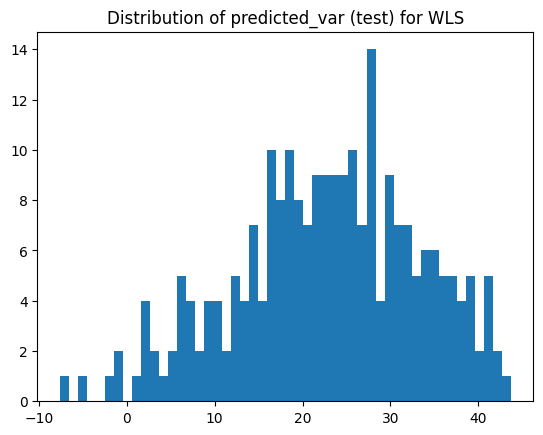

Min: -7.609705217159753
Max: 43.6993470000252


In [24]:
plt.hist(predicted_var, bins=50)
plt.title('Distribution of predicted_var (test) for WLS')
plt.show()

print('Min:', predicted_var.min())
print('Max:', predicted_var.max())

# Preparation for WLS diagnostics on test set
predicted_var_clean = np.maximum(np.asarray(predicted_var, dtype=float), MIN_VARIANCE)
weights_fgls_test = inverse_variance_weights(predicted_var_clean, min_variance=MIN_VARIANCE)

In [25]:
# WLS diagnostics on the test set without refitting the model.
# The main model and residual-variance model are estimated on train,
# and on test we only run prediction and weight diagnostics.
predicted_var_diag = model_residuals_sectors.predict(df_test_wls)
predicted_var_clean = np.maximum(np.asarray(predicted_var_diag, dtype=float), MIN_VARIANCE)
weights_wls_diag = inverse_variance_weights(predicted_var_clean, min_variance=MIN_VARIANCE)

y_pred_wls_train_fitted = model_fgls_sectors.predict(df_test_wls)

wls_test_diagnostic_df = pd.DataFrame({
    'y_true': y_test,
    'y_pred_train_fitted_wls': y_pred_wls_train_fitted,
    'predicted_residual_variance': predicted_var_clean,
    'implied_weight': weights_wls_diag,
}, index=y_test.index)

print('WLS diagnostics on test without refit: train-fitted WLS -> test')
print(f'Out-of-sample R2: {r2_score(y_test, y_pred_wls_train_fitted):.4f}')
print(f'Weighted R2 (weights from variance model trained on train): {weighted_r2(y_test, y_pred_wls_train_fitted, weights_wls_diag):.4f}')
print(wls_test_diagnostic_df.head())

WLS diagnostics on test without refit: train-fitted WLS -> test
Out-of-sample R2: 0.2472
Weighted R2 (weights from variance model trained on train): 0.2734
       y_true  y_pred_train_fitted_wls  predicted_residual_variance  \
1126   6.3595                 7.990650                    22.826095   
1064  13.7821                10.186360                     7.043230   
126    5.3407                 8.722417                     1.654480   
1018   5.0441                 8.344524                    17.928552   
922    6.6936                 8.430711                    28.295254   

      implied_weight  
1126        0.043810  
1064        0.141980  
126         0.604419  
1018        0.055777  
922         0.035342  


In [26]:
sector_vars = [
    'Sector_Communication_Services[T.True]',
    'Sector_Consumer_Cyclical[T.True]',
    'Sector_Consumer_Defensive[T.True]',
    'Sector_Energy[T.True]',
    'Sector_Financial_Services[T.True]',
    'Sector_Healthcare[T.True]',
    'Sector_Industrials[T.True]',
    'Sector_Real_Estate[T.True]',
    'Sector_Technology[T.True]',
    'Sector_Utilities[T.True]'
]

In [27]:
f_test_result_fgls = model_fgls_sectors.f_test(" = ".join([f"{var} = 0" for var in sector_vars]))

print(f_test_result_fgls)
print(model_fgls_sectors.params.index)

<F test: F=np.float64(16.394808053171975), p=1.68632073149303e-27, df_denom=933, df_num=10>
Index(['Intercept', 'Sector_Communication_Services[T.True]',
       'Sector_Consumer_Cyclical[T.True]', 'Sector_Consumer_Defensive[T.True]',
       'Sector_Energy[T.True]', 'Sector_Financial_Services[T.True]',
       'Sector_Healthcare[T.True]', 'Sector_Industrials[T.True]',
       'Sector_Real_Estate[T.True]', 'Sector_Technology[T.True]',
       'Sector_Utilities[T.True]', 'Revenue_Growth', 'grossProfitMargin',
       'returnOnEquity', 'assetTurnover', 'Debt_to_Equity',
       'Debt_to_Equity_squared', 'Capex_to_Revenue', 'R_and_D_to_Revenue',
       'Dividend_Yield', 'currentRatio', 'currentRatio_squared',
       'returnOnEquityXpositiveROE'],
      dtype='object')


c:\Users\tymot\.conda\envs\ratiosmodeling\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 19, but rank is 10
  warnings.warn('covariance of constraints does not have full '


In [28]:
hypotheses_full = """
Revenue_Growth = 0,
grossProfitMargin = 0,
returnOnEquity = 0,
returnOnEquityXpositiveROE = 0,
assetTurnover = 0,
Debt_to_Equity = 0,
Debt_to_Equity_squared = 0,
Capex_to_Revenue = 0,
R_and_D_to_Revenue = 0,
Dividend_Yield = 0,
currentRatio = 0,
currentRatio_squared = 0
"""


print(type(hypotheses_full))
print(repr(hypotheses_full))


wald_test_result = model_fgls_sectors.wald_test(hypotheses_full)

print(wald_test_result)
f_test_result_full = model_fgls_sectors.f_test(hypotheses_full)
print(f_test_result_full)
f_test_result = model_fgls_sectors.f_test(hypotheses)
print(f_test_result)
f_test_result = model_fgls_sectors.f_test(hypotheses2)
print(f_test_result)

<class 'str'>
'\nRevenue_Growth = 0,\ngrossProfitMargin = 0,\nreturnOnEquity = 0,\nreturnOnEquityXpositiveROE = 0,\nassetTurnover = 0,\nDebt_to_Equity = 0,\nDebt_to_Equity_squared = 0,\nCapex_to_Revenue = 0,\nR_and_D_to_Revenue = 0,\nDividend_Yield = 0,\ncurrentRatio = 0,\ncurrentRatio_squared = 0\n'
<F test: F=array([[21.29462323]]), p=8.221627083462583e-42, df_denom=933, df_num=12>
<F test: F=21.294623225526447, p=8.221627083462583e-42, df_denom=933, df_num=12>
<F test: F=10.033679483382521, p=4.882354568894914e-05, df_denom=933, df_num=2>
<F test: F=4.611973566474146, p=0.01015971418008504, df_denom=933, df_num=2>


c:\Users\tymot\.conda\envs\ratiosmodeling\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


In [29]:
wald_test_result = model_fgls_sectors.wald_test(hypotheses_full)

print(wald_test_result)
f_test_result_full = model_fgls_sectors.f_test(hypotheses_full)
print(f_test_result_full)
f_test_result = model_fgls_sectors.f_test(hypotheses)
print(f_test_result)
f_test_result = model_fgls_sectors.f_test(hypotheses2)
print(f_test_result)

<F test: F=array([[21.29462323]]), p=8.221627083462583e-42, df_denom=933, df_num=12>
<F test: F=21.294623225526447, p=8.221627083462583e-42, df_denom=933, df_num=12>
<F test: F=10.033679483382521, p=4.882354568894914e-05, df_denom=933, df_num=2>
<F test: F=4.611973566474146, p=0.01015971418008504, df_denom=933, df_num=2>


In [30]:
financial_vars = [
    'Revenue_Growth',
    'grossProfitMargin',
    'returnOnEquity',
    'returnOnEquityXpositiveROE',
    'assetTurnover',
    'Debt_to_Equity',
    'Debt_to_Equity_squared',
    'Capex_to_Revenue',
    'R_and_D_to_Revenue',
    'Dividend_Yield',
    'currentRatio',
    'currentRatio_squared',
]

hypothesis = ' = 0, '.join(financial_vars) + ' = 0'

wald_test_result = model_fgls_sectors.wald_test(hypothesis)
print(wald_test_result)

<F test: F=array([[21.29462323]]), p=8.221627083462583e-42, df_denom=933, df_num=12>


In [31]:
import xgboost as xgb

random_state = int(globals().get('RANDOM_STATE', 42))
n_jobs = int(globals().get('N_JOBS', -1))

df_xgboost2 = model_df.drop(columns=['Sector_label']).copy()
model_xgb_baseline = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=random_state,
    n_jobs=n_jobs,
    )
model_xgb_baseline.fit(X_train, y_train)

y_pred_xgb_baseline = model_xgb_baseline.predict(X_test)
baseline_xgb_metrics = regression_summary('XGBoost (baseline)', y_test, y_pred_xgb_baseline)

Model statistics: XGBoost (baseline)
R2        : 0.3081
MAE       : 3.6336
RMSE      : 4.7807
MAPE (%)  : 48.39


## Baseline XGBoost: Key result

Purpose: establish the first tree-based benchmark on the fixed train/test split.

Result: baseline XGBoost reaches $R^2=0.3081$, MAE $=3.6336$, RMSE $=4.7807$, MAPE $=48.39\%$.

Meaning: even without hyperparameter search, gradient boosting captures a substantial share of EV/EBITDA dispersion and sets a strong baseline for all later variants.

In [32]:
df_sectors_cook2.head()

,Enterprise_Value_over_EBITDA,Revenue_Growth,Profit_Margin,grossProfitMargin,returnOnEquity,assetTurnover,Debt_to_Equity,Debt_to_Equity_squared,Capex_to_Revenue,R_and_D_to_Revenue,...,Sector_Consumer_Cyclical,Sector_Consumer_Defensive,Sector_Energy,Sector_Financial_Services,Sector_Healthcare,Sector_Industrials,Sector_Real_Estate,Sector_Technology,Sector_Utilities,residuals
0,7.0919,0.1289,0.297,0.617336,0.2824,0.553660,0.3535,0.124962,0.2143,0.1912,...,False,False,False,False,False,False,False,True,False,64.660650
1,13.6724,0.1586,0.224,0.383437,0.5556,0.726215,1.0685,1.141692,0.0501,0.0536,...,False,False,False,False,False,False,False,True,False,7.400208
2,15.3298,0.1428,0.150,0.652474,0.2003,0.426351,0.9890,0.978121,0.1054,0.1334,...,False,False,False,False,False,False,False,True,False,0.667873
3,10.8702,0.0227,0.023,0.091095,0.1023,0.625002,4.2918,18.419547,0.0486,0.0000,...,True,False,False,False,False,False,False,False,False,5.381634
4,10.6814,0.0421,0.091,0.795343,0.0774,0.285693,1.3072,1.708772,0.0441,0.1545,...,False,False,False,False,False,False,False,True,False,19.988666


In [33]:
sector_distribution = model_df['Sector_label'].value_counts().sort_values(ascending=False)
print('Sector distribution after proper reconstruction of the base category:')
print(sector_distribution)

model_df[['Sector_label'] + sector_cols].head()

Sector distribution after proper reconstruction of the base category:
Sector_label
Industrials               274
Consumer_Cyclical         233
Technology                192
Basic_Materials           112
Healthcare                 86
Real_Estate                75
Consumer_Defensive         73
Energy                     66
Financial_Services         55
Utilities                  18
Communication_Services     11
Name: count, dtype: int64


,Sector_label,Sector_Communication_Services,Sector_Consumer_Cyclical,Sector_Consumer_Defensive,Sector_Energy,Sector_Financial_Services,Sector_Healthcare,Sector_Industrials,Sector_Real_Estate,Sector_Technology,Sector_Utilities
0,Technology,False,False,False,False,False,False,False,False,True,False
1,Technology,False,False,False,False,False,False,False,False,True,False
2,Technology,False,False,False,False,False,False,False,False,True,False
3,Consumer_Cyclical,False,True,False,False,False,False,False,False,False,False
4,Technology,False,False,False,False,False,False,False,False,True,False


In [34]:
df_xgboost_le = model_df.drop(columns=['Sector_label']).copy()

In [35]:
X_le = df_xgboost_le.drop(columns=[target_col])
y_le = df_xgboost_le[target_col]

X_le_train, X_le_test = X_train.copy(), X_test.copy()
y_le_train, y_le_test = y_train.copy(), y_test.copy()

model_xgb_le = model_xgb_baseline
y_le_pred = y_pred_xgb_baseline

print('Tree-based models use sector dummies; LabelEncoder was skipped to avoid artificial category ordering.')

Tree-based models use sector dummies; LabelEncoder was skipped to avoid artificial category ordering.


In [36]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

random_state = int(globals().get('RANDOM_STATE', 42))
n_jobs = int(globals().get('N_JOBS', -1))
cv_folds = int(globals().get('CV_FOLDS', 5))

X_tune = X_all.copy()
y_tune = y_all.copy()

X_tune_train, X_tune_test = X_train.copy(), X_test.copy()
y_tune_train, y_tune_test = y_train.copy(), y_test.copy()

pipeline = Pipeline([
    ('xgb', xgb.XGBRegressor(objective='reg:squarederror', random_state=random_state, n_jobs=n_jobs))
])

param_distributions = {
    'xgb__n_estimators': randint(150, 500),
    'xgb__max_depth': randint(3, 8),
    'xgb__learning_rate': uniform(0.01, 0.15),
    'xgb__subsample': uniform(0.6, 0.4),
    'xgb__colsample_bytree': uniform(0.6, 0.4),
    'xgb__gamma': uniform(0.0, 1.0),
    'xgb__reg_lambda': uniform(0.0, 5.0),
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring='r2',
    cv=cv_folds,
    verbose=1,
    n_jobs=n_jobs,
    random_state=random_state,
    )

search.fit(X_tune_train, y_tune_train)

y_tune_pred = search.predict(X_tune_test)
tuned_search_metrics = regression_summary('XGBoost (RandomizedSearchCV)', y_tune_test, y_tune_pred)
print('Best parameters:', search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Model statistics: XGBoost (RandomizedSearchCV)
R2        : 0.3313
MAE       : 3.5877
RMSE      : 4.6996
MAPE (%)  : 47.93
Best parameters: {'xgb__colsample_bytree': np.float64(0.9400154311159197), 'xgb__gamma': np.float64(0.4494506741382034), 'xgb__learning_rate': np.float64(0.024311517473561695), 'xgb__max_depth': 7, 'xgb__n_estimators': 248, 'xgb__reg_lambda': np.float64(2.9564889385386355), 'xgb__subsample': np.float64(0.7098887171960256)}


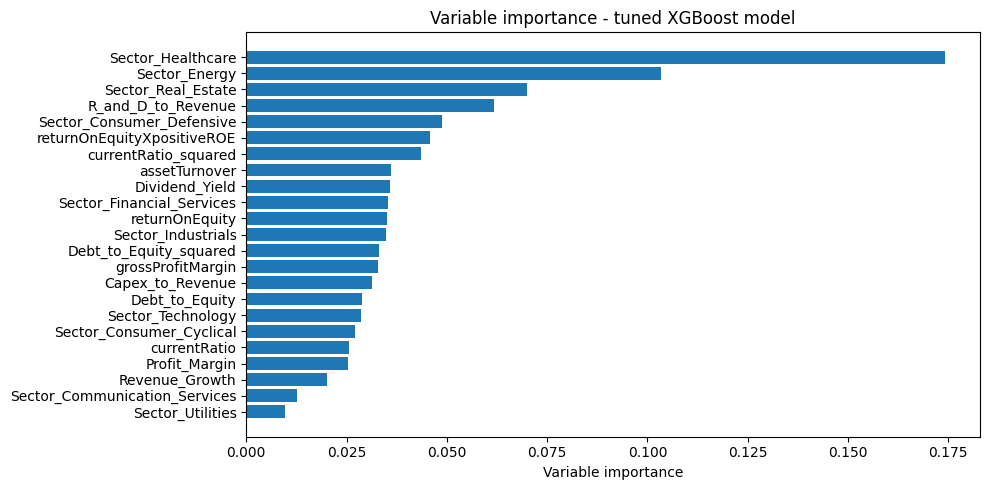

Model statistics: XGBoost (tuned)
R2        : 0.3313
MAE       : 3.5877
RMSE      : 4.6996
MAPE (%)  : 47.93


In [37]:
import xgboost as xgb

random_state = int(globals().get('RANDOM_STATE', 42))
n_jobs = int(globals().get('N_JOBS', -1))

best_xgb_params = {
    'n_estimators': 387,
    'max_depth': 4,
    'learning_rate': 0.02408322616990878,
    'subsample': 0.7434587125184655,
    'colsample_bytree': 0.9376852562905246,
    'gamma': 0.9300168348108319,
    'reg_lambda': 3.355717584120253,
}
if 'search' in globals():
    best_xgb_params.update({
        key.replace('xgb__', ''): value
        for key, value in search.best_params_.items()
    })

X_tuned = X_all.copy()
y_tuned = y_all.copy()
X_tuned_train, X_tuned_test = X_train.copy(), X_test.copy()
y_tuned_train, y_tuned_test = y_train.copy(), y_test.copy()

model_xgb = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=random_state,
    n_jobs=n_jobs,
    **best_xgb_params,
    )
model_xgb.fit(X_tuned_train, y_tuned_train)

importances = model_xgb.feature_importances_
plot_sorted_feature_importance(
    feature_names=X_tuned_train.columns,
    importances=importances,
    title='Variable importance - tuned XGBoost model',
)

y_pred_xgb = model_xgb.predict(X_tuned_test)
xgb_metrics = regression_summary('XGBoost (tuned)', y_tuned_test, y_pred_xgb)

## Tuned XGBoost: Incremental gain

Purpose: test whether hyperparameter search produces a meaningful improvement over the baseline.

Result: tuned XGBoost improves to $R^2=0.3313$ (from $0.3081$), with MAE $=3.5877$, RMSE $=4.6996$, MAPE $=47.93\%$.

Meaning: tuning yields a clear uplift in explanatory power and error reduction, so the tuned XGBoost becomes the primary single-model benchmark in the notebook.

In [38]:
eval_model(model_xgb, X_tuned_test, y_tuned_test, name='XGBoost (tuned)')

Model statistics: XGBoost (tuned)
R2        : 0.3313
MAE       : 3.5877
RMSE      : 4.6996
MAPE (%)  : 47.93


{'Model': 'XGBoost (tuned)',
 'R2': 0.3313407914258133,
 'MAE': 3.5877466284045623,
 'RMSE': np.float64(4.699638108046275),
 'MAPE (%)': np.float64(47.92966921399396)}

# Other trial models

In [39]:
df_lgbm_le = df_xgboost_le.copy()
df_lgbm_le.head()

,Enterprise_Value_over_EBITDA,Revenue_Growth,Profit_Margin,grossProfitMargin,returnOnEquity,assetTurnover,Debt_to_Equity,Debt_to_Equity_squared,Capex_to_Revenue,R_and_D_to_Revenue,...,Sector_Communication_Services,Sector_Consumer_Cyclical,Sector_Consumer_Defensive,Sector_Energy,Sector_Financial_Services,Sector_Healthcare,Sector_Industrials,Sector_Real_Estate,Sector_Technology,Sector_Utilities
0,7.0919,0.1289,0.297,0.617336,0.2824,0.553660,0.3535,0.124962,0.2143,0.1912,...,False,False,False,False,False,False,False,False,True,False
1,13.6724,0.1586,0.224,0.383437,0.5556,0.726215,1.0685,1.141692,0.0501,0.0536,...,False,False,False,False,False,False,False,False,True,False
2,15.3298,0.1428,0.150,0.652474,0.2003,0.426351,0.9890,0.978121,0.1054,0.1334,...,False,False,False,False,False,False,False,False,True,False
3,10.8702,0.0227,0.023,0.091095,0.1023,0.625002,4.2918,18.419547,0.0486,0.0000,...,False,True,False,False,False,False,False,False,False,False
4,10.6814,0.0421,0.091,0.795343,0.0774,0.285693,1.3072,1.708772,0.0441,0.1545,...,False,False,False,False,False,False,False,False,True,False


Model statistics: LightGBM
R2        : 0.3178
MAE       : 3.6081
RMSE      : 4.7469
MAPE (%)  : 48.17


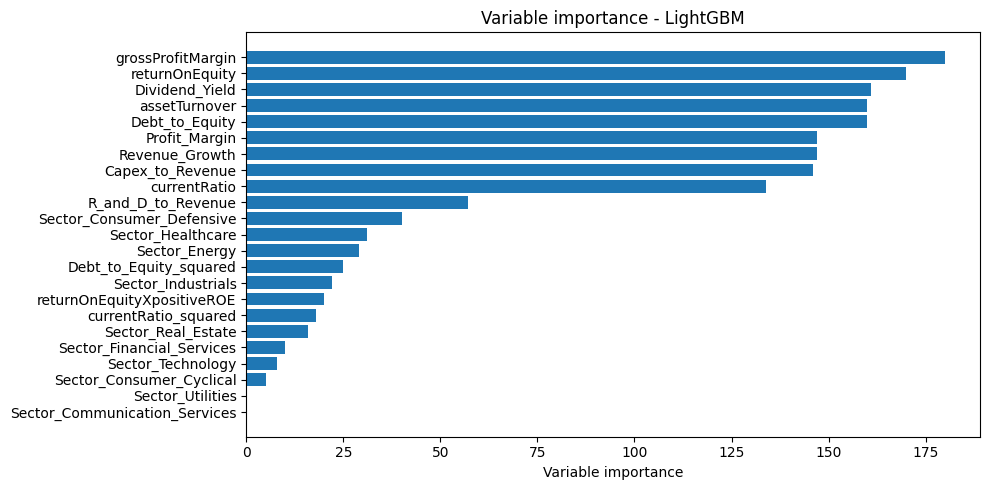

In [40]:
from lightgbm import LGBMRegressor

random_state = int(globals().get('RANDOM_STATE', 42))

df_lgbm_le = df_xgboost_le.copy()
X_lgb = X_all.copy()
y_lgb = y_all.copy()
X_lgb_train, X_lgb_test = X_train.copy(), X_test.copy()
y_lgb_train, y_lgb_test = y_train.copy(), y_test.copy()

model_lgb = LGBMRegressor(
    objective='regression',
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=random_state,
    verbosity=-1,
    )
model_lgb.fit(X_lgb_train, y_lgb_train)

y_pred_lgb = model_lgb.predict(X_lgb_test)
y_lgb_pred = y_pred_lgb
lgb_metrics = regression_summary('LightGBM', y_lgb_test, y_pred_lgb)

importances = model_lgb.feature_importances_
plot_sorted_feature_importance(
    feature_names=X_lgb_train.columns,
    importances=importances,
    title='Variable importance - LightGBM',
)

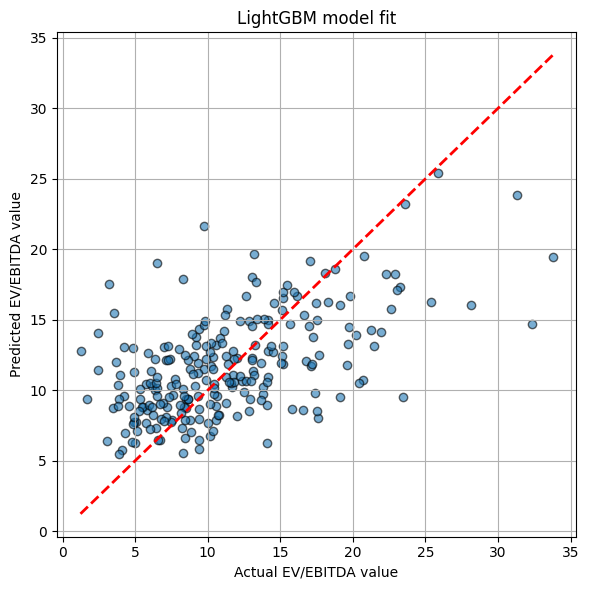

In [41]:
plt.figure(figsize=(6, 6))
plt.scatter(y_lgb_test, y_pred_lgb, alpha=0.6, edgecolor='k')
plt.plot([y_lgb_test.min(), y_lgb_test.max()], [y_lgb_test.min(), y_lgb_test.max()], 'r--', lw=2)
plt.xlabel('Actual EV/EBITDA value')
plt.ylabel('Predicted EV/EBITDA value')
plt.title('LightGBM model fit')
plt.grid(True)
plt.tight_layout()
plt.show()

c:\Users\tymot\.conda\envs\ratiosmodeling\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Company 1 - index: 163


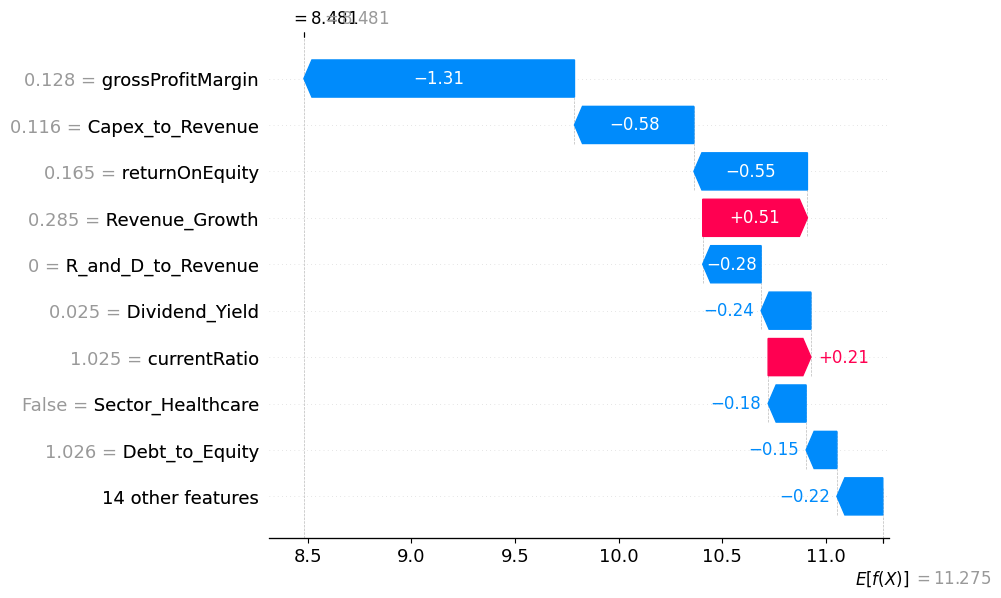


Company 2 - index: 28


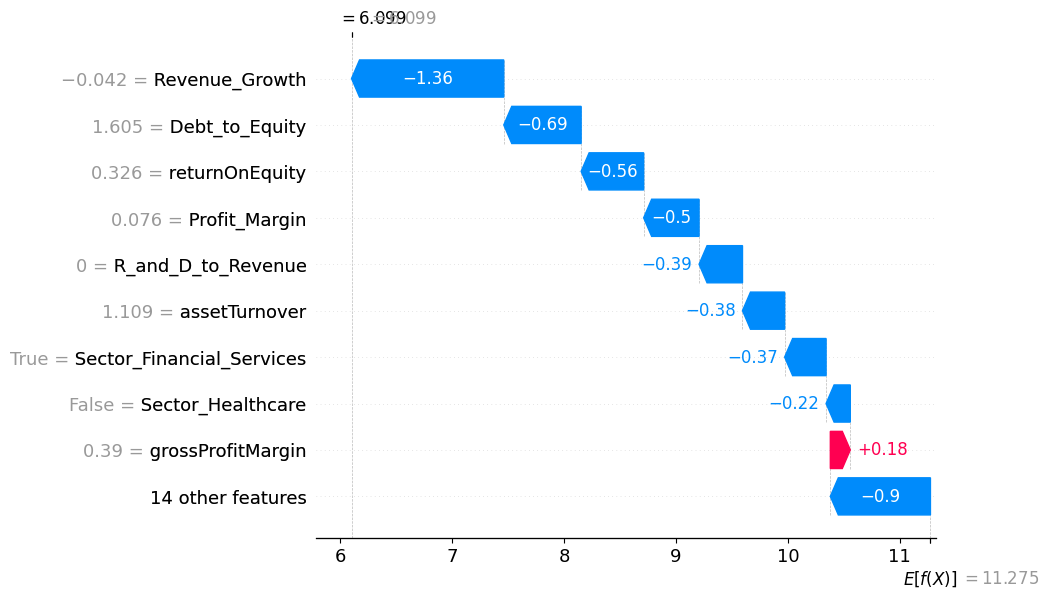


Company 3 - index: 6


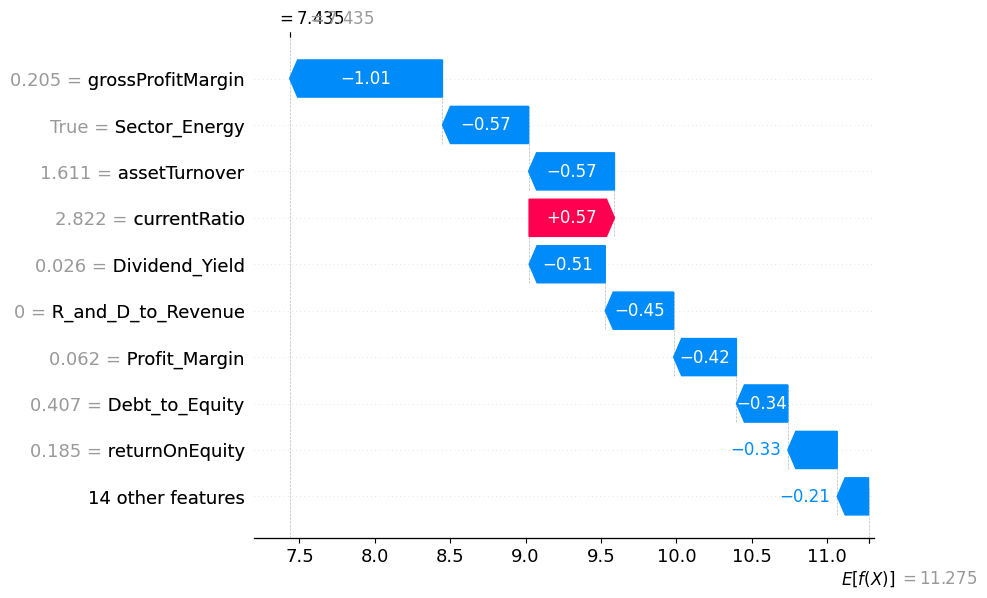


Company 4 - index: 189


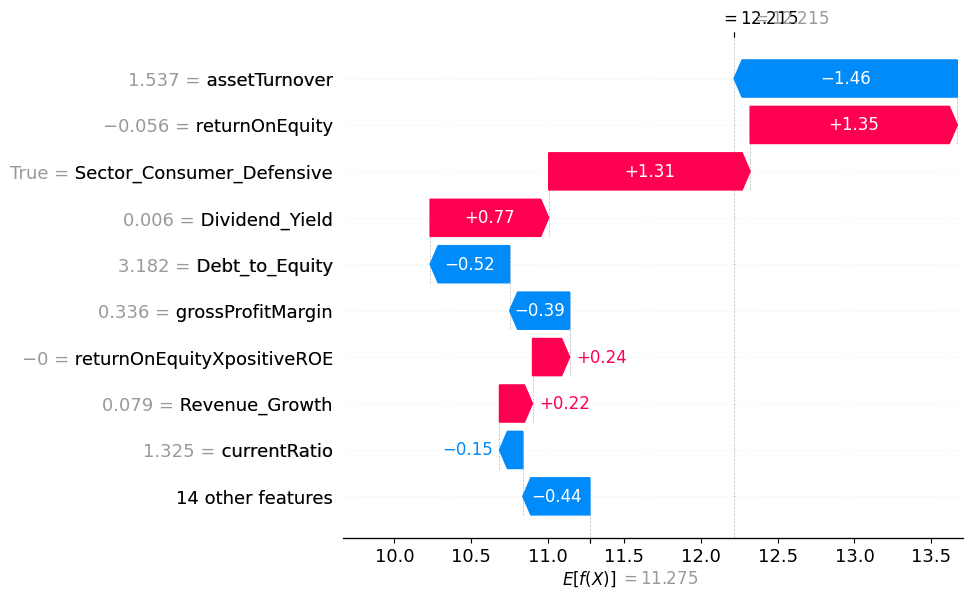


Company 5 - index: 70


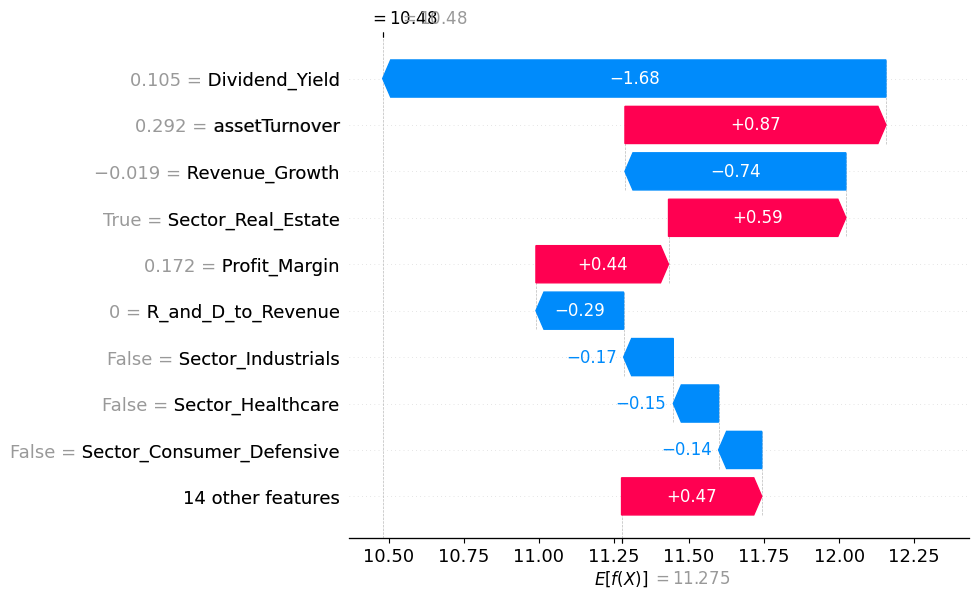

In [42]:
try:
    import shap
except Exception as exc:
    print(f"Failed to import SHAP: {exc}")
else:
    import random

    random.seed(RANDOM_STATE)

    if 'model_xgb' not in globals() or 'X_tuned_test' not in globals():
        print("SHAP skipped: first run the cell with model_xgb training.")
    else:
        sample_size = min(5, X_tuned_test.shape[0])
        sample_indices = random.sample(range(X_tuned_test.shape[0]), sample_size)
        X_sample = X_tuned_test.iloc[sample_indices]

        shap_values = None

        try:
            explainer = shap.Explainer(model_xgb, X_sample)
            shap_values = explainer(X_sample)
        except Exception:
            try:
                # Fallback for SHAP/XGBoost version combinations where generic Explainer fails.
                booster = model_xgb.get_booster() if hasattr(model_xgb, 'get_booster') else model_xgb
                xgb_sample = xgb.DMatrix(X_sample, feature_names=list(X_sample.columns))
                shap_contrib = booster.predict(xgb_sample, pred_contribs=True)
                shap_values = shap.Explanation(
                    values=shap_contrib[:, :-1],
                    base_values=shap_contrib[:, -1],
                    data=X_sample.to_numpy(),
                    feature_names=list(X_sample.columns),
                )
            except Exception as shap_exc:
                print(f"SHAP explanation skipped due to compatibility issue: {shap_exc}")

        if shap_values is not None:
            for i in range(len(X_sample)):
                print(f"\nCompany {i + 1} - index: {sample_indices[i]}")
                shap.plots.waterfall(shap_values[i], max_display=10)


In [43]:
eval_model(model_lgb, X_lgb_test, y_lgb_test, name='LightGBM')

Model statistics: LightGBM
R2        : 0.3178
MAE       : 3.6081
RMSE      : 4.7469
MAPE (%)  : 48.17


{'Model': 'LightGBM',
 'R2': 0.31782470170984856,
 'MAE': 3.6080969277010655,
 'RMSE': np.float64(4.746899056370383),
 'MAPE (%)': np.float64(48.16953812112874)}

In [44]:
df_catboost = df_xgboost_le.copy()

In [45]:
from catboost import CatBoostRegressor

random_state = int(globals().get('RANDOM_STATE', 42))

df_catboost = df_xgboost_le.copy()
X_cb = X_all.copy()
y_cb = y_all.copy()
X_cb_train, X_cb_test = X_train.copy(), X_test.copy()
y_cb_train, y_cb_test = y_train.copy(), y_test.copy()

model_cb = CatBoostRegressor(
    iterations=300,
    depth=4,
    learning_rate=0.05,
    loss_function='RMSE',
    random_seed=random_state,
    allow_writing_files=False,
    verbose=0,
    )
model_cb.fit(X_cb_train, y_cb_train)

y_cb_pred = model_cb.predict(X_cb_test)
cb_metrics = regression_summary('CatBoost', y_cb_test, y_cb_pred)

Model statistics: CatBoost
R2        : 0.2810
MAE       : 3.7163
RMSE      : 4.8733
MAPE (%)  : 49.72


In [46]:
eval_model(model_cb, X_cb_test, y_cb_test, name='CatBoost')

Model statistics: CatBoost
R2        : 0.2810
MAE       : 3.7163
RMSE      : 4.8733
MAPE (%)  : 49.72


{'Model': 'CatBoost',
 'R2': 0.28100367161926654,
 'MAE': 3.7163082265968836,
 'RMSE': np.float64(4.873324582419234),
 'MAPE (%)': np.float64(49.72269526070213)}

In [47]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

model_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0)),
    ])
model_ridge.fit(X_train, y_train)

y_pred_ridge = model_ridge.predict(X_test)
ridge_metrics = regression_summary('Ridge Regression', y_test, y_pred_ridge)

Model statistics: Ridge Regression
R2        : 0.2624
MAE       : 3.7948
RMSE      : 4.9358
MAPE (%)  : 50.30


In [48]:
from scipy.stats import randint
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

def run_random_forest_r2(X_train, X_test, y_train, y_test, n_iter=30, cv=None, random_state=None, verbose=1):
    if cv is None:
        cv = int(globals().get('CV_FOLDS', 5))
    if random_state is None:
        random_state = int(globals().get('RANDOM_STATE', 42))
    n_jobs = int(globals().get('N_JOBS', -1))

    rf = RandomForestRegressor(random_state=random_state, n_jobs=n_jobs)
    param_distributions = {
        'n_estimators': randint(200, 600),
        'max_depth': randint(3, 20),
        'min_samples_split': randint(2, 10),
        'min_samples_leaf': randint(1, 5),
        'max_features': ['sqrt', 'log2', 1.0],
    }

    search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_distributions,
        scoring='r2',
        n_iter=n_iter,
        cv=cv,
        random_state=random_state,
        verbose=verbose,
        n_jobs=n_jobs,
        )
    search.fit(X_train, y_train)
    y_pred = search.predict(X_test)

    return {
        'model': search.best_estimator_,
        'best_params': search.best_params_,
        'y_pred': y_pred,
        'metrics': regression_summary('Random Forest', y_test, y_pred),
    }

In [49]:
results_rf = run_random_forest_r2(X_train, X_test, y_train, y_test, n_iter=30)
model_rf = results_rf['model']
y_pred_rf = results_rf['y_pred']
rf_metrics = results_rf['metrics']

print('Best parameters:')
print(results_rf['best_params'])

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Model statistics: Random Forest
R2        : 0.3151
MAE       : 3.6884
RMSE      : 4.7564
MAPE (%)  : 49.64
Best parameters:
{'max_depth': 16, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 545}



Company 1 - index: 1


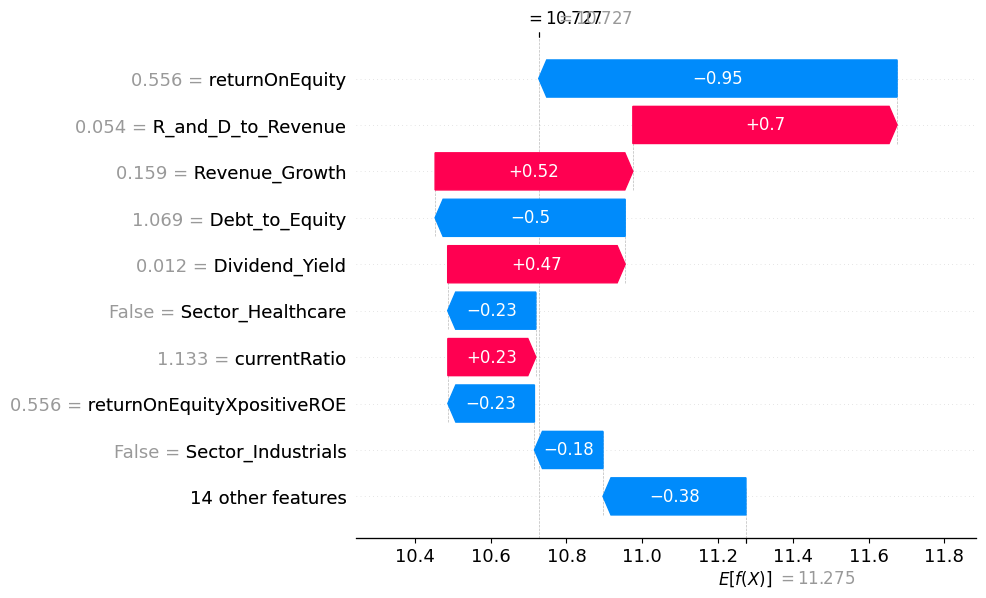


Company 2 - index: 594


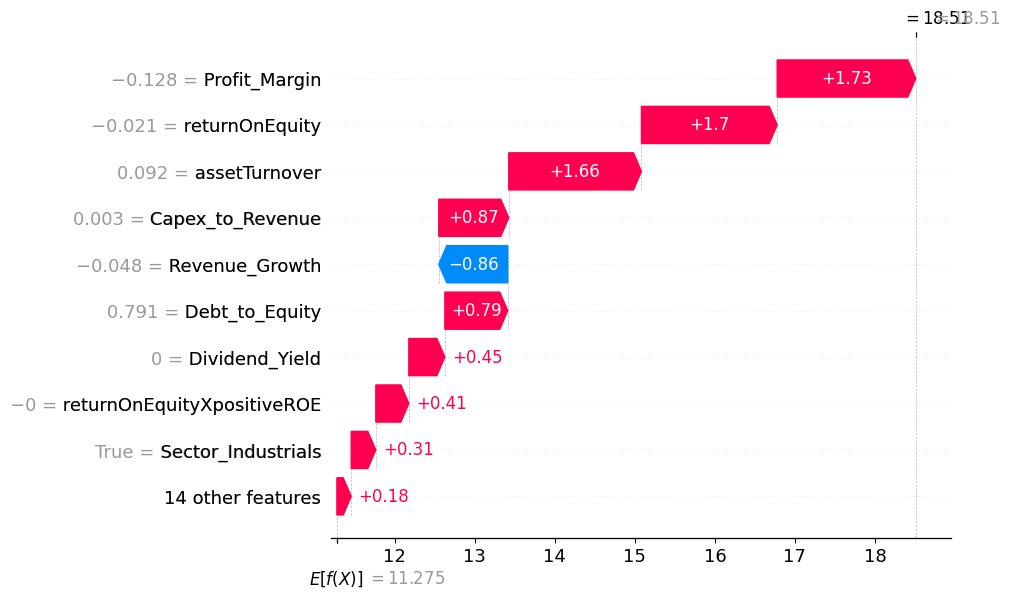


Company 3 - index: 27


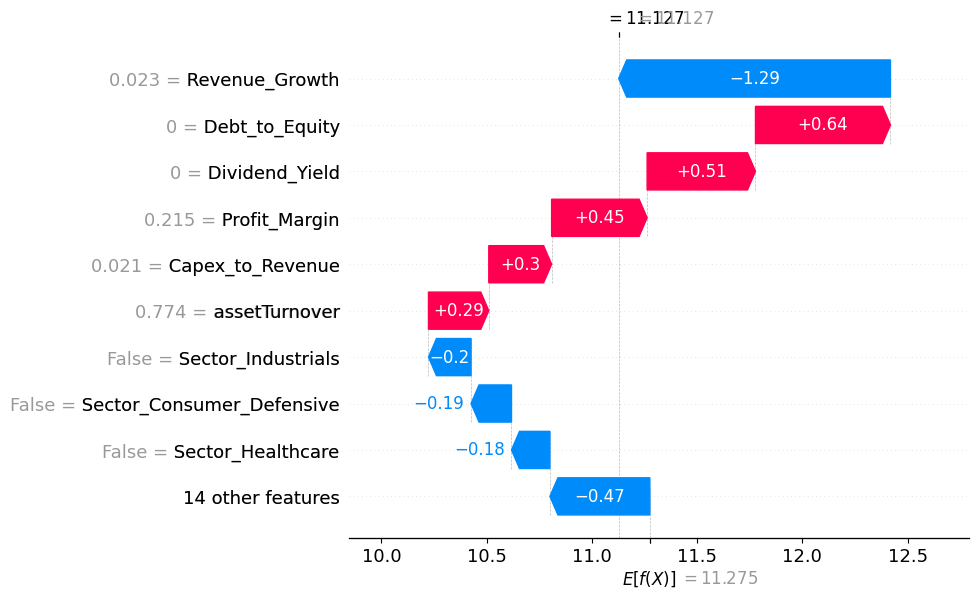


Company 4 - index: 935


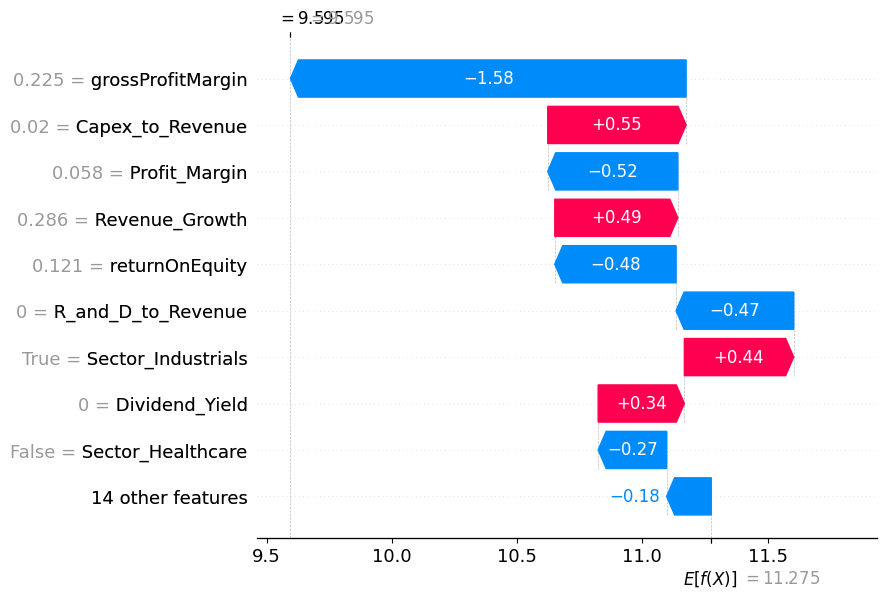


Company 5 - index: 281


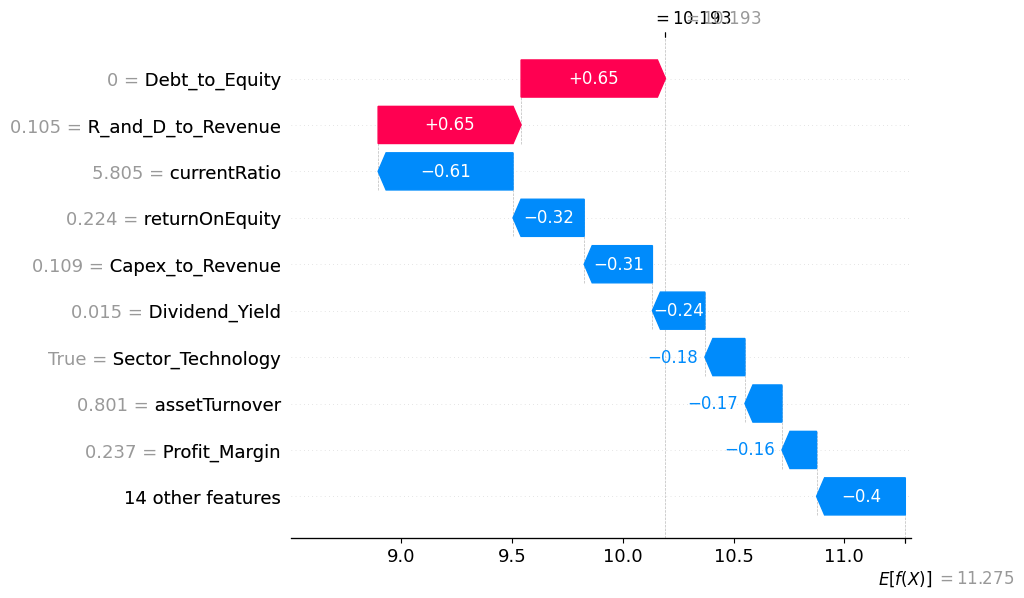

In [50]:
try:
    import shap
except Exception as exc:
    print(f'Failed to import SHAP: {exc}')
else:
    sample_size = min(5, X_tuned_test.shape[0])
    sample_index = np.random.default_rng(RANDOM_STATE).choice(X_tuned_test.index.to_numpy(), size=sample_size, replace=False)
    X_sample = X_tuned_test.loc[sample_index]

    shap_values = None

    try:
        explainer = shap.Explainer(model_xgb, X_tuned_train)
        shap_values = explainer(X_sample)
    except Exception:
        try:
            booster = model_xgb.get_booster() if hasattr(model_xgb, 'get_booster') else model_xgb
            xgb_sample = xgb.DMatrix(X_sample, feature_names=list(X_sample.columns))
            shap_contrib = booster.predict(xgb_sample, pred_contribs=True)
            shap_values = shap.Explanation(
                values=shap_contrib[:, :-1],
                base_values=shap_contrib[:, -1],
                data=X_sample.to_numpy(),
                feature_names=list(X_sample.columns),
            )
        except Exception as shap_exc:
            print(f'SHAP explanation skipped due to compatibility issue: {shap_exc}')

    if shap_values is not None:
        for row_number, row_index in enumerate(X_sample.index, start=1):
            print(f'\nCompany {row_number} - index: {row_index}')
            shap.plots.waterfall(shap_values[row_number - 1], max_display=10)

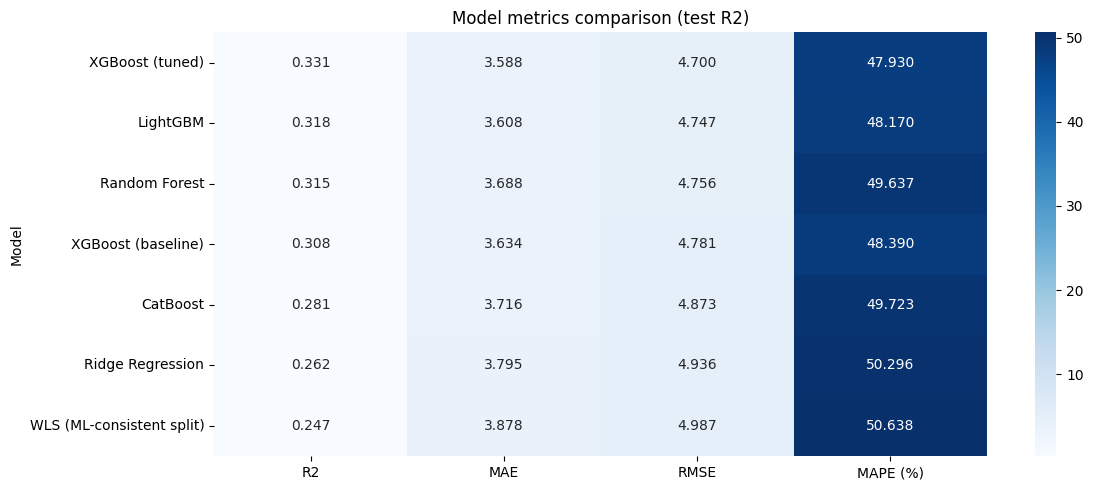

                       Model        R2       MAE      RMSE   MAPE (%)  \
0            XGBoost (tuned)  0.331341  3.587747  4.699638  47.929669   
1                   LightGBM  0.317825  3.608097  4.746899  48.169538   
2              Random Forest  0.315099  3.688361  4.756372  49.636630   
3         XGBoost (baseline)  0.308078  3.633642  4.780691  48.390322   
4                   CatBoost  0.281004  3.716308  4.873325  49.722695   
5           Ridge Regression  0.262437  3.794821  4.935845  50.296283   
6  WLS (ML-consistent split)  0.247189  3.877851  4.986607  50.638349   

   R2_train_in_sample  R2_train_unweighted  R2_train_weighted  \
0                 NaN                  NaN                NaN   
1                 NaN                  NaN                NaN   
2                 NaN                  NaN                NaN   
3                 NaN                  NaN                NaN   
4                 NaN                  NaN                NaN   
5                 NaN    

In [51]:
metric_vars = [
    'baseline_xgb_metrics',
    'xgb_metrics',
    'lgb_metrics',
    'cb_metrics',
    'ridge_metrics',
    'rf_metrics',
    'wls_metrics',
    'mlp_metrics',
    ]

model_summaries = []
for var_name in metric_vars:
    metric_obj = globals().get(var_name)
    if isinstance(metric_obj, dict):
        model_summaries.append(metric_obj)

if not model_summaries:
    print('No metrics to compare. Run model training cells.')
else:
    results_df = pd.DataFrame(model_summaries).sort_values(by='R2', ascending=False).reset_index(drop=True)
    display_columns = ['R2', 'MAE', 'RMSE', 'MAPE (%)']

    plt.figure(figsize=(12, 5))
    sns.heatmap(results_df.set_index('Model')[display_columns], annot=True, fmt='.3f', cmap='Blues')
    plt.title('Model metrics comparison (test R2)')
    plt.tight_layout()
    plt.show()

    print(results_df)

## Core model comparison: practical ranking

Purpose: compare all core model families on exactly the same test split.

Result: the heatmap ranks tuned XGBoost first ($R^2=0.331$), followed by LightGBM ($0.318$), Random Forest ($0.315$), baseline XGBoost ($0.308$), then CatBoost, Ridge, and WLS.

Meaning: tree ensembles dominate linear alternatives in this task; tuning is more valuable than switching to a different booster without tuning.

In [52]:
y_test = y_tuned_test.copy()
y_pred = y_pred_xgb.copy()

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape_val = mape(y_test, y_pred)

print(f'R2: {r2:.3f}, RMSE: {rmse:.3f}, MAE: {mae:.3f}, MAPE: {mape_val:.2f}%')

R2: 0.331, RMSE: 4.700, MAE: 3.588, MAPE: 47.93%


In [53]:
table_metrics = results_df.set_index('Model')
required_models = {'XGBoost (tuned)', 'WLS (ML-consistent split)'}
missing_models = required_models - set(table_metrics.index)
if missing_models:
    raise KeyError(f"Missing models in results_df: {sorted(missing_models)}")

r2_table_xgb = float(table_metrics.loc['XGBoost (tuned)', 'R2'])
r2_below_xgb = float(r2_score(y_tuned_test, y_pred_xgb))

r2_table_wls = float(table_metrics.loc['WLS (ML-consistent split)', 'R2'])
r2_below_wls = float(r2_score(y_test, y_pred_wls))

print(f'XGBoost R2: table={r2_table_xgb:.4f}, below={r2_below_xgb:.4f}')
print(f'WLS R2: table={r2_table_wls:.4f}, below={r2_below_wls:.4f}')
print('XGBoost consistency:', np.isclose(r2_table_xgb, r2_below_xgb))
print('WLS consistency:', np.isclose(r2_table_wls, r2_below_wls))

XGBoost R2: table=0.3313, below=0.3313
WLS R2: table=0.2472, below=0.2472
XGBoost consistency: True
WLS consistency: True


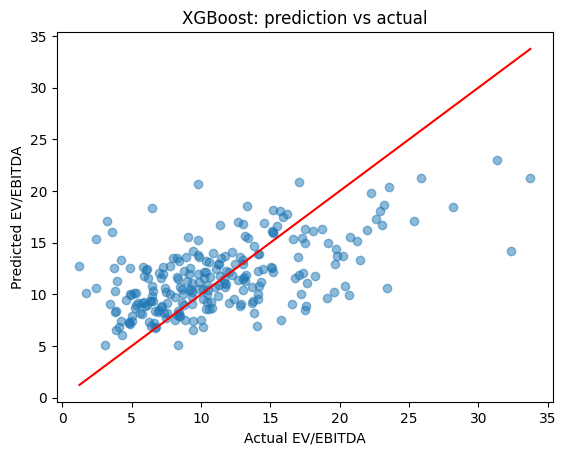

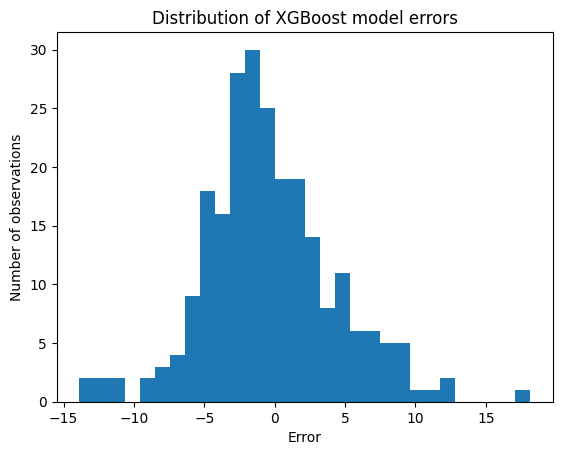

In [54]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.xlabel('Actual EV/EBITDA')
plt.ylabel('Predicted EV/EBITDA')
plt.title('XGBoost: prediction vs actual')
plt.show()

errors = y_test - y_pred
plt.hist(errors, bins=30)
plt.xlabel('Error')
plt.ylabel('Number of observations')
plt.title('Distribution of XGBoost model errors')
plt.show()

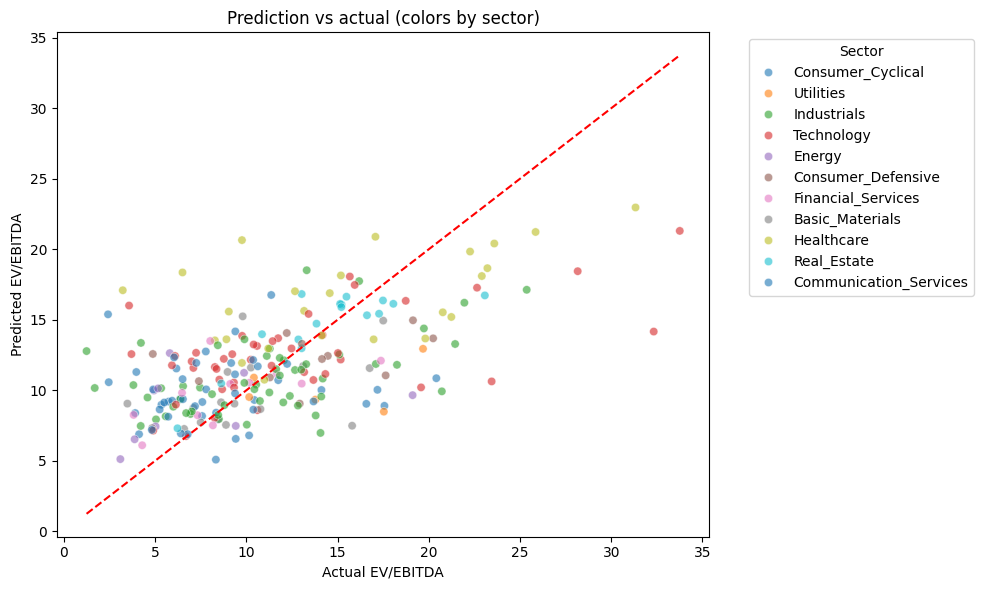

In [55]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, hue=sector_labels_test, alpha=0.6, palette='tab10')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual EV/EBITDA')
plt.ylabel('Predicted EV/EBITDA')
plt.title('Prediction vs actual (colors by sector)')
plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [56]:
errors = y_test - y_pred
abs_errors = errors.abs()
pct_errors = abs_errors / y_test.abs().replace(0, np.nan) * 100

df_errors = pd.DataFrame({
    'Sector': sector_labels_test,
    'Absolute Error': abs_errors,
    'Percentage Error': pct_errors,
})

sector_summary = df_errors.groupby('Sector').agg({
    'Absolute Error': 'mean',
    'Percentage Error': 'mean',
}).rename(columns={
    'Absolute Error': 'Mean absolute error',
    'Percentage Error': 'Mean percentage error (MAPE)',
}).round(2)

print(sector_summary)

                        Mean absolute error  Mean percentage error (MAPE)
Sector                                                                   
Basic_Materials                        2.59                         31.01
Communication_Services                 5.39                        122.56
Consumer_Cyclical                      3.64                         58.59
Consumer_Defensive                     3.51                         33.79
Energy                                 3.72                         58.87
Financial_Services                     2.42                         33.78
Healthcare                             4.89                         51.22
Industrials                            3.46                         60.14
Real_Estate                            1.73                         12.28
Technology                             4.11                         42.99
Utilities                              4.27                         25.82


In [57]:
# Feature importance (default: 'gain')
importance = model_xgb.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

# Normalization (optional)
importance_df['Importance'] = importance_df['Importance'] / importance_df['Importance'].sum()

# Rounding
importance_df['Importance'] = importance_df['Importance'].round(3)

print(importance_df)

                          Feature  Importance
18              Sector_Healthcare       0.174
16                  Sector_Energy       0.103
20             Sector_Real_Estate       0.070
8              R_and_D_to_Revenue       0.062
15      Sector_Consumer_Defensive       0.049
12     returnOnEquityXpositiveROE       0.046
11           currentRatio_squared       0.044
4                   assetTurnover       0.036
9                  Dividend_Yield       0.036
17      Sector_Financial_Services       0.035
3                  returnOnEquity       0.035
19             Sector_Industrials       0.035
6          Debt_to_Equity_squared       0.033
2               grossProfitMargin       0.033
7                Capex_to_Revenue       0.031
5                  Debt_to_Equity       0.029
21              Sector_Technology       0.029
14       Sector_Consumer_Cyclical       0.027
10                   currentRatio       0.026
1                   Profit_Margin       0.025
0                  Revenue_Growth 

## Practical interpretation: how key variables move EV/EBITDA

This section translates model drivers into valuation logic.

How to read direction in this notebook:
- In tree models, higher feature importance means stronger contribution to prediction quality, not automatically positive effect.
- Direction should be read from SHAP/correlation-of-SHAP outputs (later section), not from importance magnitude alone.

Practical channels used for EV/EBITDA interpretation:
- Revenue_Growth: sustained growth usually supports higher multiples by increasing expected operating cash-flow trajectory.
- grossProfitMargin and returnOnEquity: stronger profitability quality generally raises valuation multiples via better earnings quality and capital efficiency.
- assetTurnover: higher asset productivity tends to support multiples when not achieved via margin dilution.
- Debt_to_Equity and Debt_to_Equity_squared: leverage effect is typically non-linear; moderate leverage can be neutral/positive, excessive leverage tends to compress multiples.
- currentRatio and currentRatio_squared: liquidity can also be non-linear; both funding stress and excess idle liquidity may be penalized.
- Capex_to_Revenue and R_and_D_to_Revenue: investment intensity can lift valuation if interpreted as credible growth optionality, but can reduce near-term valuation if cash conversion weakens.
- Dividend_Yield: often captures maturity/value profile; high yield may reflect either stable cash generation or a risk discount depending on context.
- Sector dummies: sector premia/discounts shift baseline valuation levels and can materially alter conditional feature effects.

Modeling implication: use feature importance for prioritization and SHAP direction for economic narrative.

In [58]:
print(formula_sectors)

Enterprise_Value_over_EBITDA ~ Revenue_Growth + grossProfitMargin + returnOnEquity + assetTurnover + Debt_to_Equity + Debt_to_Equity_squared + Capex_to_Revenue + R_and_D_to_Revenue + Dividend_Yield + currentRatio + currentRatio_squared + returnOnEquityXpositiveROE + Sector_Communication_Services + Sector_Consumer_Cyclical + Sector_Consumer_Defensive + Sector_Energy + Sector_Financial_Services + Sector_Healthcare + Sector_Industrials + Sector_Real_Estate + Sector_Technology + Sector_Utilities


In [59]:
import statsmodels.formula.api as smf

sector_cols = [col for col in df_sectors_cook2.columns if col.startswith('Sector_')]
fgls_terms = [
    'Revenue_Growth',
    'grossProfitMargin',
    'returnOnEquity',
    'assetTurnover',
    'Debt_to_Equity',
    'Debt_to_Equity_squared',
    'Capex_to_Revenue',
    'R_and_D_to_Revenue',
    'Dividend_Yield',
    'currentRatio',
    'currentRatio_squared',
    'returnOnEquityXpositiveROE',
    ]

formula_sectors = 'Enterprise_Value_over_EBITDA ~ ' + ' + '.join(fgls_terms + sector_cols)
hypotheses = 'Debt_to_Equity = 0, Debt_to_Equity_squared = 0'
hypotheses2 = 'currentRatio = 0, currentRatio_squared = 0'
model_sectors_cook2 = smf.ols(formula=formula_sectors, data=df_sectors_cook2).fit()

print(f'Number of observations: {len(df_sectors_cook2)}')
print(formula_sectors)

Number of observations: 1195
Enterprise_Value_over_EBITDA ~ Revenue_Growth + grossProfitMargin + returnOnEquity + assetTurnover + Debt_to_Equity + Debt_to_Equity_squared + Capex_to_Revenue + R_and_D_to_Revenue + Dividend_Yield + currentRatio + currentRatio_squared + returnOnEquityXpositiveROE + Sector_Communication_Services + Sector_Consumer_Cyclical + Sector_Consumer_Defensive + Sector_Energy + Sector_Financial_Services + Sector_Healthcare + Sector_Industrials + Sector_Real_Estate + Sector_Technology + Sector_Utilities


In [60]:
df_sectors_fgls = df_sectors_cook2.drop(columns=['residuals'], errors='ignore').copy()
df_sectors_fgls['residuals'] = model_sectors_cook2.resid ** 2
df_sectors_fgls.head()

,Enterprise_Value_over_EBITDA,Revenue_Growth,Profit_Margin,grossProfitMargin,returnOnEquity,assetTurnover,Debt_to_Equity,Debt_to_Equity_squared,Capex_to_Revenue,R_and_D_to_Revenue,...,Sector_Consumer_Cyclical,Sector_Consumer_Defensive,Sector_Energy,Sector_Financial_Services,Sector_Healthcare,Sector_Industrials,Sector_Real_Estate,Sector_Technology,Sector_Utilities,residuals
0,7.0919,0.1289,0.297,0.617336,0.2824,0.553660,0.3535,0.124962,0.2143,0.1912,...,False,False,False,False,False,False,False,True,False,64.660650
1,13.6724,0.1586,0.224,0.383437,0.5556,0.726215,1.0685,1.141692,0.0501,0.0536,...,False,False,False,False,False,False,False,True,False,7.400208
2,15.3298,0.1428,0.150,0.652474,0.2003,0.426351,0.9890,0.978121,0.1054,0.1334,...,False,False,False,False,False,False,False,True,False,0.667873
3,10.8702,0.0227,0.023,0.091095,0.1023,0.625002,4.2918,18.419547,0.0486,0.0000,...,True,False,False,False,False,False,False,False,False,5.381634
4,10.6814,0.0421,0.091,0.795343,0.0774,0.285693,1.3072,1.708772,0.0441,0.1545,...,False,False,False,False,False,False,False,True,False,19.988666


In [61]:
financial_vars = [
    'Revenue_Growth',
    'grossProfitMargin',
    'returnOnEquity',
    'returnOnEquityXpositiveROE',
    'assetTurnover',
    'Debt_to_Equity',
    'Debt_to_Equity_squared',
    'Capex_to_Revenue',
    'R_and_D_to_Revenue',
    'Dividend_Yield',
    'currentRatio',
    'currentRatio_squared',
    ]

hypothesis = ' = 0, '.join(financial_vars) + ' = 0'
wald_test_result = model_fgls_sectors.wald_test(hypothesis)
print(wald_test_result)

<F test: F=array([[21.29462323]]), p=8.221627083462583e-42, df_denom=933, df_num=12>


c:\Users\tymot\.conda\envs\ratiosmodeling\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


In [62]:
ensemble_context = {
    'ensemble_xgb_metrics': globals().get('ensemble_xgb_metrics'),
    'valid_rmse': globals().get('valid_rmse'),
    'ensemble_weights': globals().get('ensemble_weights'),
    'test_pred_ensemble': globals().get('test_pred_ensemble'),
    'model_ensemble_xgb': globals().get('model_ensemble_xgb'),
    'model_ensemble_lgb': globals().get('model_ensemble_lgb'),
    'model_ensemble_cb': globals().get('model_ensemble_cb'),
    }

missing_ensemble_vars = [name for name, value in ensemble_context.items() if value is None]

print('xgb_metrics:', xgb_metrics)
if missing_ensemble_vars:
    print('Ensemble diagnostics skipped until later section is executed.')
    print('Missing variables:', missing_ensemble_vars)
else:
    ensemble_xgb_metrics_local = ensemble_context['ensemble_xgb_metrics']
    valid_rmse_local = ensemble_context['valid_rmse']
    ensemble_weights_local = ensemble_context['ensemble_weights']
    test_pred_ensemble_local = ensemble_context['test_pred_ensemble']
    model_ensemble_xgb_local = ensemble_context['model_ensemble_xgb']
    model_ensemble_lgb_local = ensemble_context['model_ensemble_lgb']
    model_ensemble_cb_local = ensemble_context['model_ensemble_cb']

    print('ensemble_xgb_metrics:', ensemble_xgb_metrics_local)
    print('valid_rmse:', valid_rmse_local)
    print('ensemble_weights:', ensemble_weights_local)

    # Quick diagnostics: whether blending reduces/changes error vs pure XGB
    xgb_abs_err = np.abs(y_test - y_pred_xgb)
    ens_abs_err = np.abs(y_test - test_pred_ensemble_local)
    print('Mean |error| XGB:', float(np.mean(xgb_abs_err)))
    print('Mean |error| ENS:', float(np.mean(ens_abs_err)))
    print('Share of observations where ENS is better than XGB:', float(np.mean(ens_abs_err < xgb_abs_err)))

    # Are base models too similar (low diversification)?
    ens_xgb_test = model_ensemble_xgb_local.predict(X_test)
    ens_lgb_test = model_ensemble_lgb_local.predict(X_test)
    ens_cb_test = model_ensemble_cb_local.predict(X_test)
    pred_corr = pd.DataFrame({
        'xgb': ens_xgb_test,
        'lgb': ens_lgb_test,
        'cb': ens_cb_test,
    }).corr()
    print('Correlation of base model predictions:')
    print(pred_corr.round(4))

xgb_metrics: {'Model': 'XGBoost (tuned)', 'R2': 0.3313407914258133, 'MAE': 3.5877466284045623, 'RMSE': np.float64(4.699638108046275), 'MAPE (%)': np.float64(47.92966921399396)}
Ensemble diagnostics skipped until later section is executed.
Missing variables: ['ensemble_xgb_metrics', 'valid_rmse', 'ensemble_weights', 'test_pred_ensemble', 'model_ensemble_xgb', 'model_ensemble_lgb', 'model_ensemble_cb']


## Ensemble at the end of the notebook (priority: tuned XGBoost)

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import xgboost as xgb

random_state = int(globals().get('RANDOM_STATE', 42))
test_size = float(globals().get('TEST_SIZE', 0.2))
n_jobs = int(globals().get('N_JOBS', -1))

ens_bins = pd.qcut(y_train.rank(method='first'), q=10, labels=False, duplicates='drop')
X_ens_train, X_ens_valid, y_ens_train, y_ens_valid = train_test_split(
    X_train,
    y_train,
    test_size=test_size,
    random_state=random_state,
    stratify=ens_bins,
    )

model_ensemble_xgb = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=random_state,
    n_jobs=n_jobs,
    **best_xgb_params,
    )
model_ensemble_lgb = LGBMRegressor(
    objective='regression',
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=random_state,
    verbosity=-1,
    )
model_ensemble_cb = CatBoostRegressor(
    iterations=300,
    depth=4,
    learning_rate=0.05,
    loss_function='RMSE',
    random_seed=random_state,
    allow_writing_files=False,
    verbose=0,
    )

model_ensemble_xgb.fit(X_ens_train, y_ens_train)
model_ensemble_lgb.fit(X_ens_train, y_ens_train)
model_ensemble_cb.fit(X_ens_train, y_ens_train)

valid_pred_xgb = model_ensemble_xgb.predict(X_ens_valid)
valid_pred_lgb = model_ensemble_lgb.predict(X_ens_valid)
valid_pred_cb = model_ensemble_cb.predict(X_ens_valid)

valid_rmse = {
    'xgb': np.sqrt(mean_squared_error(y_ens_valid, valid_pred_xgb)),
    'lgb': np.sqrt(mean_squared_error(y_ens_valid, valid_pred_lgb)),
    'cb': np.sqrt(mean_squared_error(y_ens_valid, valid_pred_cb)),
    }
inv_rmse = {name: 1.0 / score for name, score in valid_rmse.items()}
inv_sum = sum(inv_rmse.values())
ensemble_weights = {name: score / inv_sum for name, score in inv_rmse.items()}

min_xgb_weight = 0.50
if ensemble_weights['xgb'] < min_xgb_weight:
    remaining = 1.0 - min_xgb_weight
    other_sum = ensemble_weights['lgb'] + ensemble_weights['cb']
    if other_sum > 0:
        ensemble_weights['lgb'] = remaining * (ensemble_weights['lgb'] / other_sum)
        ensemble_weights['cb'] = remaining * (ensemble_weights['cb'] / other_sum)
    else:
        ensemble_weights['lgb'] = remaining / 2
        ensemble_weights['cb'] = remaining / 2
    ensemble_weights['xgb'] = min_xgb_weight

test_pred_ensemble = (
    ensemble_weights['xgb'] * model_ensemble_xgb.predict(X_test)
    + ensemble_weights['lgb'] * model_ensemble_lgb.predict(X_test)
    + ensemble_weights['cb'] * model_ensemble_cb.predict(X_test)
    )

ensemble_xgb_metrics = regression_summary(
    'Ensemble (XGB_tuned + LGBM + CatBoost)',
    y_test,
    test_pred_ensemble,
    )

print('Validation RMSE of base models:', valid_rmse)
print('Ensemble weights (after enforcing min. 50% for XGB):', ensemble_weights)

Model statistics: Ensemble (XGB_tuned + LGBM + CatBoost)
R2        : 0.3180
MAE       : 3.6492
RMSE      : 4.7464
MAPE (%)  : 47.89
Validation RMSE of base models: {'xgb': np.float64(4.977205069239054), 'lgb': np.float64(4.998474263255401), 'cb': np.float64(4.983798095162949)}
Ensemble weights (after enforcing min. 50% for XGB): {'xgb': 0.5, 'lgb': np.float64(0.2496324442079544), 'cb': np.float64(0.25036755579204556)}


## Additional methods to increase R2 (3 proposals)
Below are three implemented variants: OOF stacking, log1p target transformation, and a global model with sector residual correction.

In [64]:
from sklearn.base import clone
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.ensemble import ExtraTreesRegressor
from catboost import CatBoostRegressor
import xgboost as xgb

random_state = int(globals().get('RANDOM_STATE', 42))
n_jobs = int(globals().get('N_JOBS', -1))
cv_folds = int(globals().get('CV_FOLDS', 5))

stack_base_models = {
    'xgb': xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=random_state,
        n_jobs=n_jobs,
        **best_xgb_params,
    ),
    'et': ExtraTreesRegressor(
        n_estimators=600,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=random_state,
        n_jobs=n_jobs,
    ),
    'cb': CatBoostRegressor(
        iterations=300,
        depth=4,
        learning_rate=0.05,
        loss_function='RMSE',
        random_seed=random_state,
        allow_writing_files=False,
        verbose=0,
    ),
}

stack_cv = KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
model_names = list(stack_base_models.keys())

oof_meta_train = np.zeros((X_train.shape[0], len(model_names)))
oof_meta_test_folds = np.zeros((stack_cv.get_n_splits(), X_test.shape[0], len(model_names)))

for fold_idx, (train_idx, valid_idx) in enumerate(stack_cv.split(X_train), start=1):
    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]
    X_fold_valid = X_train.iloc[valid_idx]

    print(f'Fold {fold_idx}/{cv_folds}')
    for model_pos, model_name in enumerate(model_names):
        fold_model = clone(stack_base_models[model_name])
        fold_model.fit(X_fold_train, y_fold_train)

        oof_meta_train[valid_idx, model_pos] = fold_model.predict(X_fold_valid)
        oof_meta_test_folds[fold_idx - 1, :, model_pos] = fold_model.predict(X_test)

oof_meta_test = oof_meta_test_folds.mean(axis=0)
base_pred_df = pd.DataFrame(oof_meta_test, columns=model_names, index=X_test.index)
print('Correlation of base model predictions (test):')
print(base_pred_df.corr().round(4))

stack_meta_model = Ridge(alpha=1.0)
stack_meta_model.fit(oof_meta_train, y_train)

y_pred_oof_stack = stack_meta_model.predict(oof_meta_test)
oof_stack_metrics = regression_summary(
    'OOF Stacking (XGB + ExtraTrees + CatBoost)',
    y_test,
    y_pred_oof_stack,
    )

meta_coefs = pd.Series(stack_meta_model.coef_, index=model_names).sort_values(ascending=False)
print('Ridge meta-model weights:')
print(meta_coefs.round(4))

Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Correlation of base model predictions (test):
        xgb      et      cb
xgb  1.0000  0.9020  0.9554
et   0.9020  1.0000  0.9382
cb   0.9554  0.9382  1.0000
Model statistics: OOF Stacking (XGB + ExtraTrees + CatBoost)
R2        : 0.3049
MAE       : 3.6705
RMSE      : 4.7917
MAPE (%)  : 48.60
Ridge meta-model weights:
et     0.5883
xgb    0.5621
cb     0.0178
dtype: float64


In [65]:
import xgboost as xgb

target_shift = float(max(0.0, -y_train.min() + 1e-6))
y_train_log = np.log1p(y_train + target_shift)

model_xgb_log1p = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    **best_xgb_params,
    )
model_xgb_log1p.fit(X_train, y_train_log)

y_pred_log_space = model_xgb_log1p.predict(X_test)
y_pred_xgb_log1p = np.expm1(y_pred_log_space) - target_shift

xgb_log1p_metrics = regression_summary(
    'XGBoost (log1p target)',
    y_test,
    y_pred_xgb_log1p,
    )

print(f'Target shift applied for log1p: {target_shift:.6f}')

Model statistics: XGBoost (log1p target)
R2        : 0.3102
MAE       : 3.5699
RMSE      : 4.7735
MAPE (%)  : 43.52
Target shift applied for log1p: 0.000000


In [66]:
import xgboost as xgb

model_xgb_global = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    **best_xgb_params,
    )
model_xgb_global.fit(X_train, y_train)

y_pred_global_train = model_xgb_global.predict(X_train)
y_pred_global_test = model_xgb_global.predict(X_test)

sector_labels_train = model_df.loc[X_train.index, 'Sector_label']
sector_labels_test_local = model_df.loc[X_test.index, 'Sector_label']

train_residuals_global = pd.Series(
    y_train - y_pred_global_train,
    index=X_train.index,
    )
sector_residual_correction = train_residuals_global.groupby(sector_labels_train).mean()
test_sector_correction = sector_labels_test_local.map(sector_residual_correction).fillna(0.0)

y_pred_global_local = y_pred_global_test + test_sector_correction.to_numpy()
global_local_sector_metrics = regression_summary(
    'XGBoost + sector residual correction',
    y_test,
    y_pred_global_local,
    )

print('Mean residual corrections by sector (top 10 by absolute value):')
print(sector_residual_correction.abs().sort_values(ascending=False).head(10))

Model statistics: XGBoost + sector residual correction
R2        : 0.3313
MAE       : 3.5806
RMSE      : 4.6999
MAPE (%)  : 48.00
Mean residual corrections by sector (top 10 by absolute value):
Sector_label
Communication_Services    0.441829
Basic_Materials           0.370579
Consumer_Defensive        0.328936
Healthcare                0.302415
Financial_Services        0.227288
Real_Estate               0.180895
Energy                    0.153411
Utilities                 0.138748
Industrials               0.127694
Consumer_Cyclical         0.082488
Name: Enterprise_Value_over_EBITDA, dtype: float64


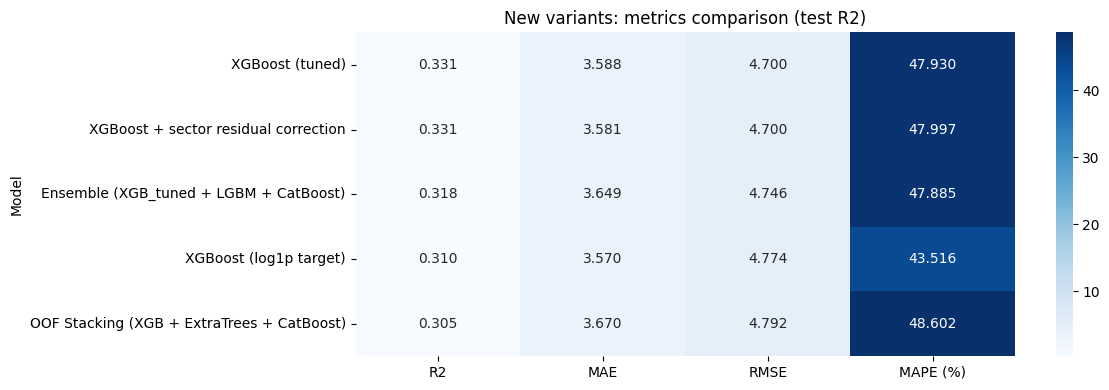

                                        Model        R2       MAE      RMSE  \
0                             XGBoost (tuned)  0.331341  3.587747  4.699638   
1        XGBoost + sector residual correction  0.331263  3.580627  4.699912   
2      Ensemble (XGB_tuned + LGBM + CatBoost)  0.317978  3.649205  4.746364   
3                      XGBoost (log1p target)  0.310156  3.569936  4.773505   
4  OOF Stacking (XGB + ExtraTrees + CatBoost)  0.304881  3.670456  4.791723   

    MAPE (%)  
0  47.929669  
1  47.997063  
2  47.885347  
3  43.516221  
4  48.602471  


In [67]:
new_methods_metric_vars = [
    'xgb_metrics',
    'ensemble_xgb_metrics',
    'oof_stack_metrics',
    'xgb_log1p_metrics',
    'global_local_sector_metrics',
    ]

new_methods_summaries = []
for metric_name in new_methods_metric_vars:
    metric_dict = globals().get(metric_name)
    if isinstance(metric_dict, dict):
        new_methods_summaries.append(metric_dict)

if not new_methods_summaries:
    print('No metrics for new methods. Run cells with new variants.')
else:
    new_methods_df = pd.DataFrame(new_methods_summaries).sort_values(by='R2', ascending=False).reset_index(drop=True)
    display_cols = ['R2', 'MAE', 'RMSE', 'MAPE (%)']

    plt.figure(figsize=(12, 4))
    sns.heatmap(new_methods_df.set_index('Model')[display_cols], annot=True, fmt='.3f', cmap='Blues')
    plt.title('New variants: metrics comparison (test R2)')
    plt.tight_layout()
    plt.show()

    print(new_methods_df)

## Additional R2-improvement variants: what worked

Purpose: test whether ensembling, target transformation, or sector-residual correction can beat tuned XGBoost.

Result: none of the three variants exceeds tuned XGBoost in $R^2$ (ensemble $0.318$, OOF stacking $0.305$, log1p target $0.310$, global+sector correction $0.331$). The log1p variant improves MAPE (about $43.5\%$) but not $R^2$.

Meaning: for this objective (maximizing explained variance), tuned XGBoost remains the most effective option; alternative variants mainly change error profile rather than improve top-line $R^2$.

## Substantive R2-first protocol (model selection without MAPE ranking)
In this block, the model is selected by mean R2 from repeated cross-validation; the test set is used only for final metrics reporting.

In [68]:
from sklearn.base import clone
from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from catboost import CatBoostRegressor
import xgboost as xgb

random_state = int(globals().get('RANDOM_STATE', 42))
n_jobs = int(globals().get('N_JOBS', -1))
cv_folds = int(globals().get('CV_FOLDS', 5))

r2_cv = RepeatedKFold(n_splits=cv_folds, n_repeats=2, random_state=random_state)

r2_protocol_models = {
    'XGBoost (tuned)': xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=random_state,
        n_jobs=n_jobs,
        **best_xgb_params,
    ),
    'ExtraTrees': ExtraTreesRegressor(
        n_estimators=600,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=random_state,
        n_jobs=n_jobs,
    ),
    'CatBoost': CatBoostRegressor(
        iterations=300,
        depth=4,
        learning_rate=0.05,
        loss_function='RMSE',
        random_seed=random_state,
        allow_writing_files=False,
        verbose=0,
    ),
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1.0)),
    ]),
}

r2_protocol_rows = []
r2_protocol_fitted_models = {}
r2_protocol_test_preds = {}

for model_name, model_obj in r2_protocol_models.items():
    cv_scores = cross_validate(
        clone(model_obj),
        X_train,
        y_train,
        cv=r2_cv,
        scoring='r2',
        n_jobs=n_jobs,
        return_train_score=False,
    )

    cv_r2_mean = float(np.mean(cv_scores['test_score']))
    cv_r2_std = float(np.std(cv_scores['test_score']))

    fitted_model = clone(model_obj)
    fitted_model.fit(X_train, y_train)
    y_pred_test_local = predict_with_model_features(fitted_model, X_test)
    test_r2_local = float(r2_score(y_test, y_pred_test_local))

    r2_protocol_rows.append({
        'Model': model_name,
        'CV_R2_mean': cv_r2_mean,
        'CV_R2_std': cv_r2_std,
        'Test_R2': test_r2_local,
    })
    r2_protocol_fitted_models[model_name] = fitted_model
    r2_protocol_test_preds[model_name] = y_pred_test_local

wls_cv_scores = []
for train_idx, valid_idx in r2_cv.split(X_train):
    X_fold_train = X_train.iloc[train_idx].copy()
    y_fold_train = y_train.iloc[train_idx].copy()
    X_fold_valid = X_train.iloc[valid_idx].copy()
    y_fold_valid = y_train.iloc[valid_idx].copy()

    df_fold_train = X_fold_train.copy()
    df_fold_train[target_col] = y_fold_train
    df_fold_valid = X_fold_valid.copy()
    df_fold_valid[target_col] = y_fold_valid

    fold_wls_model, fold_resid_model = fit_two_step_wls(
        train_df=df_fold_train,
        formula_main=formula_sectors,
        formula_resid=formula_residuals_sectors,
    )
    y_fold_valid_pred = fold_wls_model.predict(df_fold_valid)
    wls_cv_scores.append(r2_score(y_fold_valid, y_fold_valid_pred))

df_protocol_train_wls = X_train.copy()
df_protocol_train_wls[target_col] = y_train
df_protocol_test_wls = X_test.copy()
df_protocol_test_wls[target_col] = y_test
protocol_wls_model, protocol_wls_resid_model = fit_two_step_wls(
    train_df=df_protocol_train_wls,
    formula_main=formula_sectors,
    formula_resid=formula_residuals_sectors,
    )
y_pred_wls_protocol_test = protocol_wls_model.predict(df_protocol_test_wls)

r2_protocol_rows.append({
    'Model': 'WLS (ML-consistent split)',
    'CV_R2_mean': float(np.mean(wls_cv_scores)),
    'CV_R2_std': float(np.std(wls_cv_scores)),
    'Test_R2': float(r2_score(y_test, y_pred_wls_protocol_test)),
})
r2_protocol_fitted_models['WLS (ML-consistent split)'] = protocol_wls_model
r2_protocol_test_preds['WLS (ML-consistent split)'] = y_pred_wls_protocol_test

r2_protocol_df = pd.DataFrame(r2_protocol_rows).sort_values(by='CV_R2_mean', ascending=False).reset_index(drop=True)
print('Model ranking by mean R2 from repeated CV:')
print(r2_protocol_df)

selected_r2_model_name = r2_protocol_df.loc[0, 'Model']
selected_r2_model = r2_protocol_fitted_models[selected_r2_model_name]
selected_r2_test_pred = r2_protocol_test_preds[selected_r2_model_name]

r2_first_selected_metrics = regression_summary(
    f"{selected_r2_model_name} [R2-first selected]",
    y_test,
    selected_r2_test_pred,
    )
r2_first_selected_metrics['CV_R2_mean'] = float(r2_protocol_df.loc[0, 'CV_R2_mean'])
r2_first_selected_metrics['CV_R2_std'] = float(r2_protocol_df.loc[0, 'CV_R2_std'])

print(f"Model selected by the R2-first protocol: {selected_r2_model_name}")

Model ranking by mean R2 from repeated CV:
                       Model  CV_R2_mean  CV_R2_std   Test_R2
0            XGBoost (tuned)    0.268594   0.058704  0.331341
1                 ExtraTrees    0.266095   0.030279  0.275445
2                   CatBoost    0.265727   0.037918  0.281004
3           Ridge Regression    0.253807   0.053221  0.262437
4  WLS (ML-consistent split)    0.237524   0.056122  0.247189
Model statistics: XGBoost (tuned) [R2-first selected]
R2        : 0.3313
MAE       : 3.5877
RMSE      : 4.6996
MAPE (%)  : 47.93
Model selected by the R2-first protocol: XGBoost (tuned)


## R2-first selection protocol: decision outcome

Purpose: avoid selecting a model by a single split and prioritize repeated-CV mean $R^2$.

Result: the protocol selects tuned XGBoost as the top model; WLS is clearly lower (CV mean $R^2 \approx 0.238$, test $R^2 \approx 0.247$).

Meaning: model choice is stable under repeated resampling, not only on one holdout split, which increases confidence that tuned XGBoost is the robust winner for this dataset.

## Extended XAI and valuation interpretation (priority: tuned XGBoost)

Purpose: convert predictive performance into economically interpretable valuation signals.

What this block delivers:
1. Global relevance: permutation importance (R2 drop) and SHAP mean absolute contribution.
2. Directional effect: SHAP sign structure and feature-SHAP correlation.
3. Local diagnosis: waterfall explanations for highest-error observations.

How to interpret practical impact on EV/EBITDA in this section:
- Larger mean absolute SHAP value -> variable has larger marginal influence on valuation predictions.
- Positive SHAP for a firm -> pushes predicted EV/EBITDA upward for that observation.
- Negative SHAP for a firm -> pushes predicted EV/EBITDA downward.
- Corr(feature, SHAP) > 0 -> higher feature levels are associated with higher predicted multiples in this sample.
- Corr(feature, SHAP) < 0 -> higher feature levels are associated with lower predicted multiples in this sample.

Use this section to separate two questions:
- Which variables matter most globally?
- For a specific company, which variables explain why its predicted multiple is high or low?

Top 15 features by permutation importance (R2 drop):
                      Feature  Permutation_R2_drop_mean  \
8          R_and_D_to_Revenue                  0.079717   
9              Dividend_Yield                  0.077216   
4               assetTurnover                  0.074886   
2           grossProfitMargin                  0.061021   
0              Revenue_Growth                  0.059052   
1               Profit_Margin                  0.045717   
5              Debt_to_Equity                  0.033793   
3              returnOnEquity                  0.025316   
18          Sector_Healthcare                  0.024469   
10               currentRatio                  0.018462   
15  Sector_Consumer_Defensive                  0.013030   
19         Sector_Industrials                  0.009446   
16              Sector_Energy                  0.006017   
7            Capex_to_Revenue                  0.005883   
20         Sector_Real_Estate                  0.004583   

  

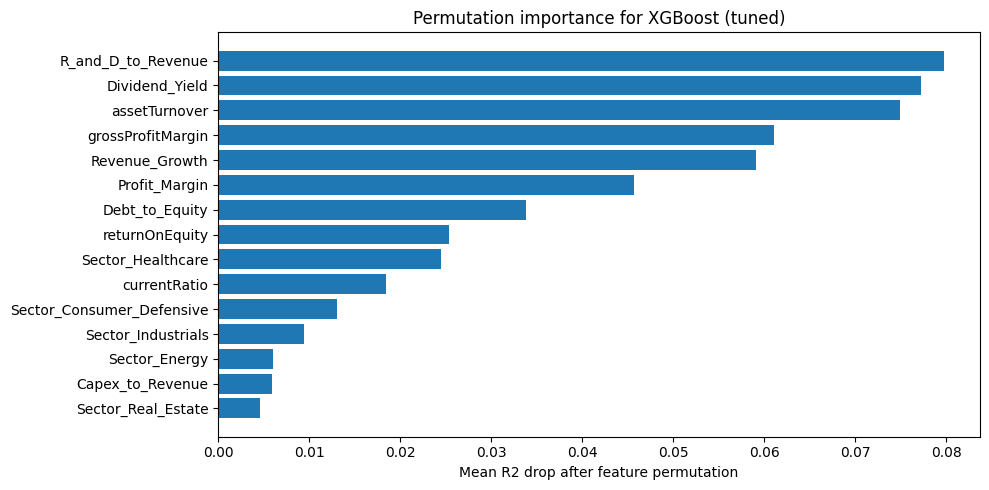

Top 15 features by mean |SHAP| (XGBoost pred_contribs):
                       Feature  MeanAbsSHAP
2            grossProfitMargin     0.705866
8           R_and_D_to_Revenue     0.637233
9               Dividend_Yield     0.626450
0               Revenue_Growth     0.578494
4                assetTurnover     0.570266
3               returnOnEquity     0.519242
18           Sector_Healthcare     0.517274
1                Profit_Margin     0.450895
7             Capex_to_Revenue     0.399954
5               Debt_to_Equity     0.319037
10                currentRatio     0.229607
16               Sector_Energy     0.198977
19          Sector_Industrials     0.167558
15   Sector_Consumer_Defensive     0.164361
12  returnOnEquityXpositiveROE     0.143534


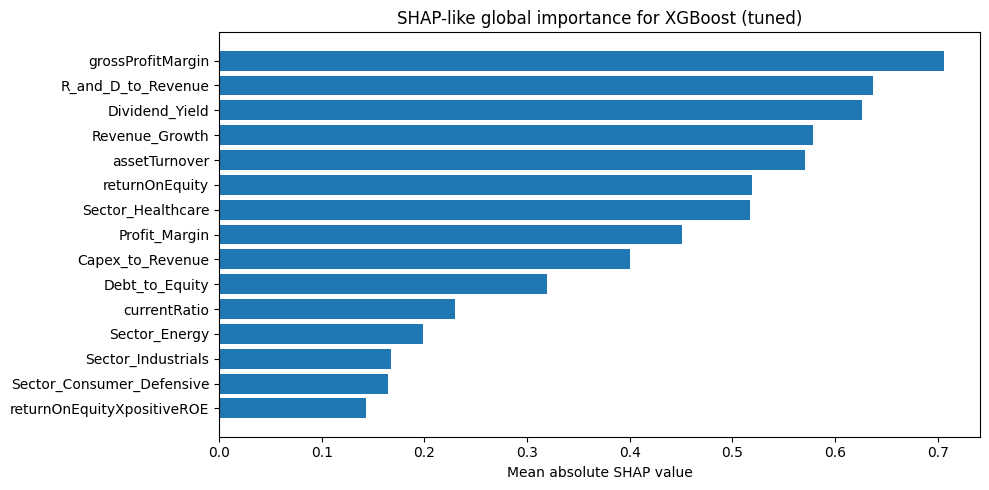

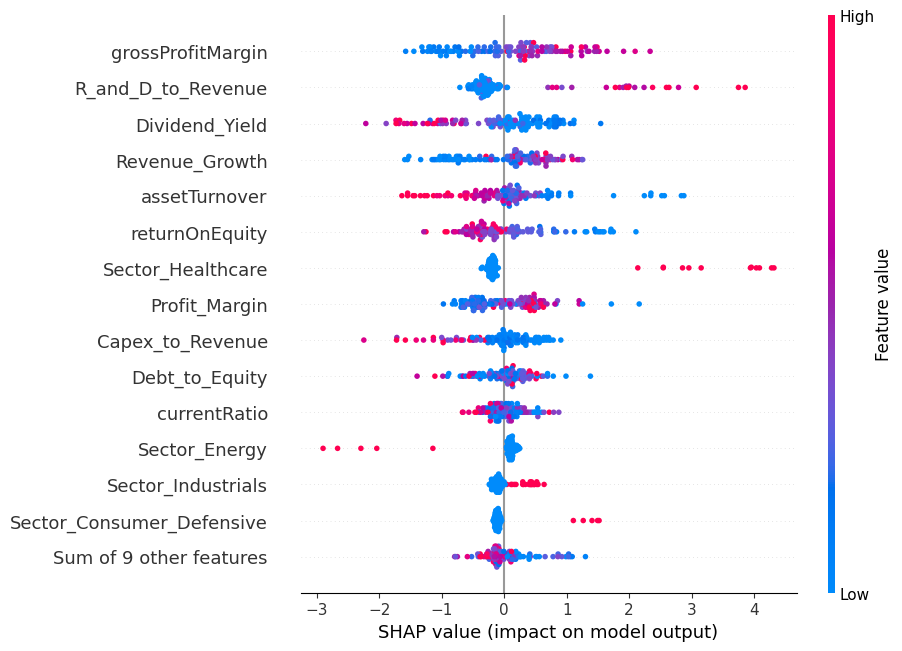

Local XAI for 3 observations with the largest error (in SHAP-like sample):
Observation index=859, |error|=18.1679


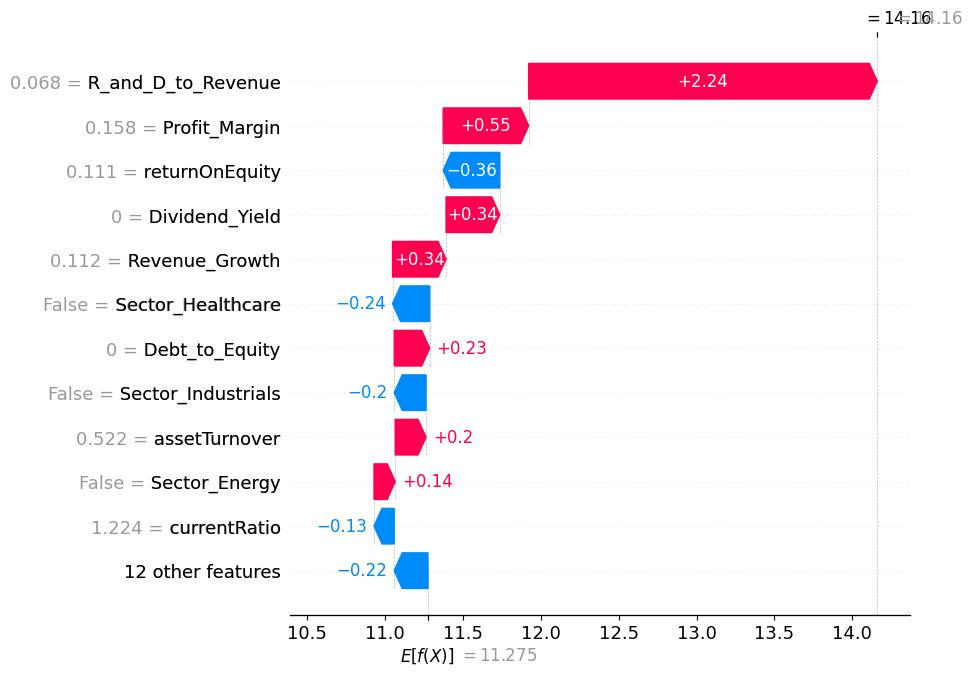

Observation index=1106, |error|=12.9692


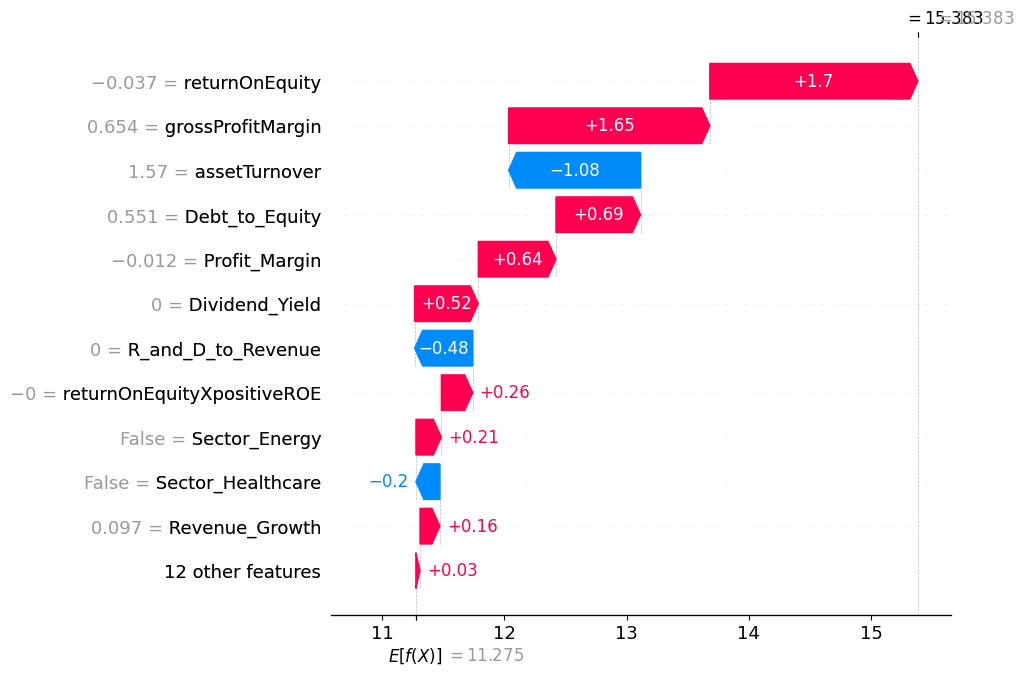

Observation index=787, |error|=12.8172


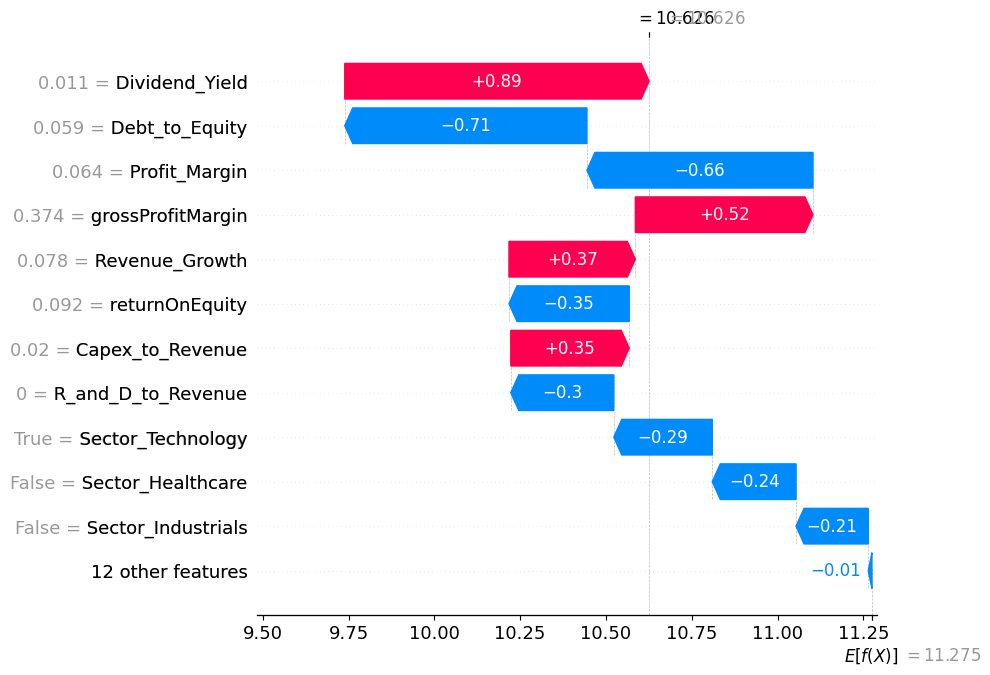

In [69]:
from sklearn.inspection import permutation_importance
import xgboost as xgb

random_state = int(globals().get('RANDOM_STATE', 42))
n_jobs = int(globals().get('N_JOBS', -1))

xai_model = model_xgb
xai_model_name = 'XGBoost (tuned)'

perm_result = permutation_importance(
    xai_model,
    X_test,
    y_test,
    scoring='r2',
    n_repeats=25,
    random_state=random_state,
    n_jobs=n_jobs,
    )
perm_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Permutation_R2_drop_mean': perm_result.importances_mean,
    'Permutation_R2_drop_std': perm_result.importances_std,
}).sort_values(by='Permutation_R2_drop_mean', ascending=False)

print('Top 15 features by permutation importance (R2 drop):')
print(perm_importance_df.head(15))

plt.figure(figsize=(10, 5))
top_perm = perm_importance_df.head(15).iloc[::-1]
plt.barh(top_perm['Feature'], top_perm['Permutation_R2_drop_mean'])
plt.xlabel('Mean R2 drop after feature permutation')
plt.title(f'Permutation importance for {xai_model_name}')
plt.tight_layout()
plt.show()

try:
    import shap
except Exception as exc:
    print(f'Failed to import SHAP: {exc}')
else:
    xai_sample_size = min(120, X_test.shape[0])
    rng = np.random.default_rng(random_state)
    xai_sample_idx = rng.choice(X_test.index.to_numpy(), size=xai_sample_size, replace=False)
    X_xai_sample = X_test.loc[xai_sample_idx]
    y_xai_sample = y_test.loc[xai_sample_idx]

    xai_dmatrix = xgb.DMatrix(X_xai_sample, feature_names=list(X_xai_sample.columns))
    shap_contrib = xai_model.get_booster().predict(xai_dmatrix, pred_contribs=True)
    shap_array = shap_contrib[:, :-1]
    base_values = shap_contrib[:, -1]

    shap_values = shap.Explanation(
        values=shap_array,
        base_values=base_values,
        data=X_xai_sample.to_numpy(),
        feature_names=list(X_xai_sample.columns),
    )

    shap_global_df = pd.DataFrame({
        'Feature': X_xai_sample.columns,
        'MeanAbsSHAP': np.abs(shap_array).mean(axis=0),
    }).sort_values(by='MeanAbsSHAP', ascending=False)

    print('Top 15 features by mean |SHAP| (XGBoost pred_contribs):')
    print(shap_global_df.head(15))

    plt.figure(figsize=(10, 5))
    top_shap = shap_global_df.head(15).iloc[::-1]
    plt.barh(top_shap['Feature'], top_shap['MeanAbsSHAP'])
    plt.xlabel('Mean absolute SHAP value')
    plt.title(f'SHAP-like global importance for {xai_model_name}')
    plt.tight_layout()
    plt.show()

    shap.plots.beeswarm(shap_values, max_display=15)

    xai_pred_sample = predict_with_model_features(xai_model, X_xai_sample)
    xai_abs_err_sample = pd.Series(
        np.abs(y_xai_sample.to_numpy() - xai_pred_sample),
        index=X_xai_sample.index,
    )
    worst_obs_idx = xai_abs_err_sample.sort_values(ascending=False).head(3).index

    print('Local XAI for 3 observations with the largest error (in SHAP-like sample):')
    for obs_idx in worst_obs_idx:
        pos = X_xai_sample.index.get_loc(obs_idx)
        print(f'Observation index={obs_idx}, |error|={xai_abs_err_sample.loc[obs_idx]:.4f}')
        shap.plots.waterfall(shap_values[pos], max_display=12)

In [70]:
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ---------- SHAP-based practical conclusions ----------
if all(name in globals() for name in ['shap_global_df', 'shap_values', 'X_xai_sample']):
    top_n = min(10, len(shap_global_df))
    top_features = shap_global_df['Feature'].head(top_n).tolist()

    shap_conclusion_rows = []
    for feat in top_features:
        feat_pos = list(X_xai_sample.columns).index(feat)
        x_vals = X_xai_sample[feat].to_numpy(dtype=float)
        s_vals = shap_values.values[:, feat_pos].astype(float)

        corr_feat_shap = np.corrcoef(x_vals, s_vals)[0, 1] if np.unique(x_vals).size > 1 else np.nan
        q_low = np.nanquantile(x_vals, 0.25)
        q_high = np.nanquantile(x_vals, 0.75)

        low_mask = x_vals <= q_low
        high_mask = x_vals >= q_high

        mean_shap_low = float(np.nanmean(s_vals[low_mask])) if low_mask.any() else np.nan
        mean_shap_high = float(np.nanmean(s_vals[high_mask])) if high_mask.any() else np.nan

        if np.isnan(corr_feat_shap):
            direction = 'non-monotonic / mixed effect'
        elif corr_feat_shap > 0:
            direction = 'higher ratio -> higher predicted EV/EBITDA'
        else:
            direction = 'higher ratio -> lower predicted EV/EBITDA'

        shap_conclusion_rows.append({
            'Feature': feat,
            'MeanAbsSHAP': float(np.abs(s_vals).mean()),
            'Corr(feature, SHAP)': corr_feat_shap,
            'Mean SHAP (low quartile)': mean_shap_low,
            'Mean SHAP (high quartile)': mean_shap_high,
            'Conclusion': direction,
        })

    shap_conclusions_df = pd.DataFrame(shap_conclusion_rows).sort_values('MeanAbsSHAP', ascending=False).reset_index(drop=True)
    print('Practical SHAP conclusions for top features:')
    print(shap_conclusions_df)

    print('\nKey valuation takeaways (top 5 by SHAP impact):')
    for _, row in shap_conclusions_df.head(5).iterrows():
        print(
            f"- {row['Feature']}: {row['Conclusion']} "
            f"(impact={row['MeanAbsSHAP']:.4f}, corr={row['Corr(feature, SHAP)']:.3f})"
        )
else:
    print('SHAP conclusion block skipped: run the Extended XAI section first.')

# ---------- Sector statistical differences in valuation multiples ----------
if 'model_df' in globals() and target_col in model_df.columns and 'Sector_label' in model_df.columns:
    sector_val_df = model_df[['Sector_label', target_col]].dropna().copy()
    sector_val_df = sector_val_df.rename(columns={'Sector_label': 'Sector', target_col: 'EV_EBITDA'})

    sector_counts = sector_val_df['Sector'].value_counts()
    valid_sectors = sector_counts[sector_counts >= 8].index.tolist()
    sector_val_df = sector_val_df[sector_val_df['Sector'].isin(valid_sectors)]

    sector_summary_df = sector_val_df.groupby('Sector')['EV_EBITDA'].agg(
        Count='size',
        Mean='mean',
        Median='median',
        Std='std',
        Q25=lambda x: np.quantile(x, 0.25),
        Q75=lambda x: np.quantile(x, 0.75),
    ).sort_values('Median', ascending=False).round(3)

    grouped = [grp['EV_EBITDA'].to_numpy() for _, grp in sector_val_df.groupby('Sector')]
    if len(grouped) >= 2:
        h_stat, p_kw = kruskal(*grouped)
        n = len(sector_val_df)
        k = len(grouped)
        epsilon_sq = max(0.0, (h_stat - k + 1) / (n - k)) if n > k else np.nan
    else:
        h_stat, p_kw, epsilon_sq = np.nan, np.nan, np.nan

    # Pairwise tests for the largest sectors (keeps the output compact and stable).
    top_sectors_for_pairs = sector_counts.head(8).index.tolist()
    pair_rows = []
    pvals = []
    pairs = []
    for i in range(len(top_sectors_for_pairs)):
        for j in range(i + 1, len(top_sectors_for_pairs)):
            s1, s2 = top_sectors_for_pairs[i], top_sectors_for_pairs[j]
            v1 = sector_val_df.loc[sector_val_df['Sector'] == s1, 'EV_EBITDA'].to_numpy()
            v2 = sector_val_df.loc[sector_val_df['Sector'] == s2, 'EV_EBITDA'].to_numpy()
            if len(v1) < 5 or len(v2) < 5:
                continue
            stat_u, p_u = mannwhitneyu(v1, v2, alternative='two-sided')
            pvals.append(p_u)
            pairs.append((s1, s2, stat_u, p_u))

    if pvals:
        reject, pvals_adj, _, _ = multipletests(pvals, alpha=0.05, method='holm')
        for (s1, s2, stat_u, p_u), p_adj, rej in zip(pairs, pvals_adj, reject):
            med_diff = float(np.median(
                sector_val_df.loc[sector_val_df['Sector'] == s1, 'EV_EBITDA']
            ) - np.median(
                sector_val_df.loc[sector_val_df['Sector'] == s2, 'EV_EBITDA']
            ))
            pair_rows.append({
                'Sector_A': s1,
                'Sector_B': s2,
                'Median_diff_A_minus_B': med_diff,
                'p_raw': p_u,
                'p_holm': p_adj,
                'Significant_5pct': bool(rej),
            })
        sector_pairwise_df = pd.DataFrame(pair_rows).sort_values('p_holm').reset_index(drop=True)
    else:
        sector_pairwise_df = pd.DataFrame(columns=[
            'Sector_A', 'Sector_B', 'Median_diff_A_minus_B', 'p_raw', 'p_holm', 'Significant_5pct'
        ])

    print('\nSector EV/EBITDA summary (sorted by median):')
    print(sector_summary_df)

    print(f"\nKruskal-Wallis test across sectors: H={h_stat:.3f}, p={p_kw:.3e}, epsilon^2={epsilon_sq:.3f}")
    if pd.notna(p_kw) and p_kw < 0.05:
        print('Conclusion: sector membership is statistically associated with different EV/EBITDA levels.')
    else:
        print('Conclusion: no strong global evidence of sector-level EV/EBITDA differences.')

    if not sector_pairwise_df.empty:
        sig_pairs = sector_pairwise_df[sector_pairwise_df['Significant_5pct']]
        print(f"\nSignificant pairwise sector differences (Holm-adjusted): {len(sig_pairs)}")
        print(sig_pairs.head(12))
    else:
        print('\nPairwise sector tests skipped or insufficient data.')

    print('\nHighest-median sectors (top 3):')
    print(sector_summary_df.head(3)[['Median', 'Count']])
    print('\nLowest-median sectors (bottom 3):')
    print(sector_summary_df.tail(3)[['Median', 'Count']])
else:
    print('Sector-difference block skipped: required columns not found in model_df.')

Practical SHAP conclusions for top features:
              Feature  MeanAbsSHAP  Corr(feature, SHAP)  \
0   grossProfitMargin     0.705866             0.743754   
1  R_and_D_to_Revenue     0.637233             0.919118   
2      Dividend_Yield     0.626450            -0.785378   
3      Revenue_Growth     0.578494             0.607618   
4       assetTurnover     0.570266            -0.822744   
5      returnOnEquity     0.519242            -0.701422   
6   Sector_Healthcare     0.517274             0.976039   
7       Profit_Margin     0.450895             0.283023   
8    Capex_to_Revenue     0.399954            -0.699607   
9      Debt_to_Equity     0.319037             0.001635   

   Mean SHAP (low quartile)  Mean SHAP (high quartile)  \
0                 -0.985325                   0.991033   
1                 -0.321508                   1.425273   
2                  0.334372                  -1.085188   
3                 -0.906327                   0.497796   
4              

## Data-driven conclusions from SHAP and sector valuation differences

The blocks below produce explicit, result-level conclusions (not only interpretation rules):
1. Which financial ratios push EV/EBITDA up or down in the tuned XGBoost model.
2. Whether sectors differ statistically in EV/EBITDA multiples and which sectors are most distinct.

Model statistics: XGBoost (tuned)
R2        : 0.3313
MAE       : 3.5877
RMSE      : 4.6996
MAPE (%)  : 47.93
Model statistics: ExtraTrees
R2        : 0.2754
MAE       : 3.7133
RMSE      : 4.8921
MAPE (%)  : 48.87
Model statistics: CatBoost
R2        : 0.2810
MAE       : 3.7163
RMSE      : 4.8733
MAPE (%)  : 49.72
Model statistics: Ridge Regression
R2        : 0.2624
MAE       : 3.7948
RMSE      : 4.9358
MAPE (%)  : 50.30
Model statistics: WLS (ML-consistent split)
R2        : 0.2472
MAE       : 3.8779
RMSE      : 4.9866
MAPE (%)  : 50.64
Final model leaderboard (priority: mean R2 from repeated CV):
                       Model  CV_R2_mean  CV_R2_std        R2       MAE  \
0            XGBoost (tuned)    0.268594   0.058704  0.331341  3.587747   
1                 ExtraTrees    0.266095   0.030279  0.275445  3.713267   
2                   CatBoost    0.265727   0.037918  0.281004  3.716308   
3           Ridge Regression    0.253807   0.053221  0.262437  3.794821   
4  WLS (ML-consiste

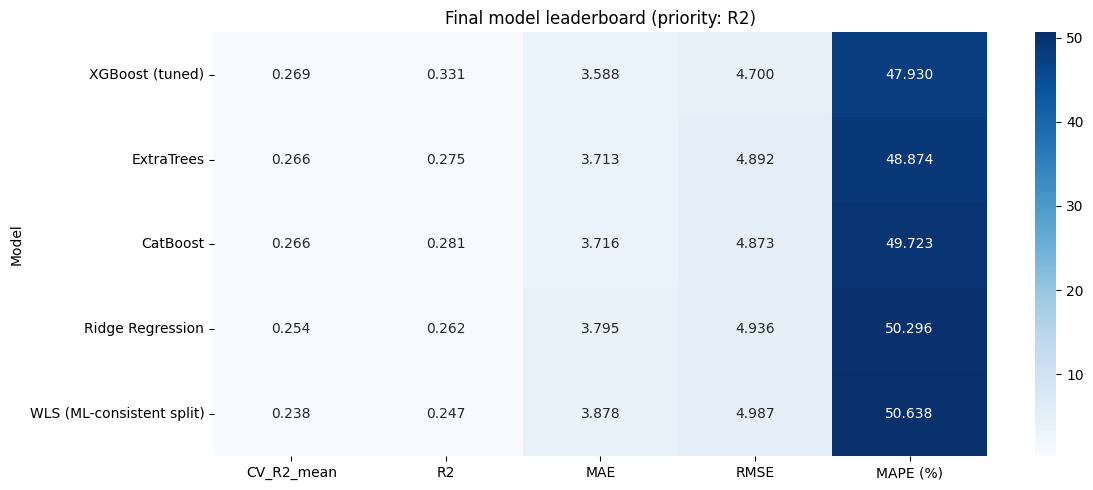

In [72]:
# Build a robust final leaderboard even if cells were run out of order.
if 'r2_protocol_test_preds' not in globals():
    r2_protocol_test_preds = {}
    fallback_preds = {
        'XGBoost (tuned)': globals().get('y_pred_xgb'),
        'LightGBM': globals().get('y_pred_lgb'),
        'CatBoost': globals().get('y_cb_pred'),
        'Ridge Regression': globals().get('y_pred_ridge'),
        'Random Forest': globals().get('y_pred_rf'),
        'WLS (ML-consistent split)': globals().get('y_pred_wls'),
    }
    for model_name, pred in fallback_preds.items():
        if pred is not None:
            r2_protocol_test_preds[model_name] = np.asarray(pred)

if 'r2_protocol_df' not in globals() or r2_protocol_df is None or len(r2_protocol_df) == 0:
    if 'r2_protocol_rows' in globals() and len(r2_protocol_rows) > 0:
        r2_protocol_df = pd.DataFrame(r2_protocol_rows).sort_values(
            by='CV_R2_mean', ascending=False
        ).reset_index(drop=True)
    elif 'results_df' in globals() and len(results_df) > 0:
        fallback_rows = []
        for row in results_df.to_dict('records'):
            fallback_rows.append({
                'Model': row['Model'],
                'CV_R2_mean': float(row.get('R2', np.nan)),
                'CV_R2_std': np.nan,
            })
        r2_protocol_df = pd.DataFrame(fallback_rows).sort_values(
            by='CV_R2_mean', ascending=False
        ).reset_index(drop=True)
    elif r2_protocol_test_preds:
        fallback_rows = []
        for model_name, y_pred_model in r2_protocol_test_preds.items():
            fallback_rows.append({
                'Model': model_name,
                'CV_R2_mean': float(r2_score(y_test, y_pred_model)),
                'CV_R2_std': np.nan,
            })
        r2_protocol_df = pd.DataFrame(fallback_rows).sort_values(
            by='CV_R2_mean', ascending=False
        ).reset_index(drop=True)
    else:
        raise RuntimeError(
            'Missing model-ranking inputs. Run the R2-first protocol section or at least core model-training cells first.'
        )

final_protocol_rows = []
for row in r2_protocol_df.to_dict('records'):
    model_name = row['Model']
    if model_name not in r2_protocol_test_preds:
        continue
    y_pred_model = np.asarray(r2_protocol_test_preds[model_name])
    summary_row = regression_summary(model_name, y_test, y_pred_model)
    summary_row['CV_R2_mean'] = float(row.get('CV_R2_mean', np.nan))
    summary_row['CV_R2_std'] = float(row.get('CV_R2_std', np.nan))
    final_protocol_rows.append(summary_row)

if not final_protocol_rows:
    raise RuntimeError(
        'No predictions available for final leaderboard. Run model prediction cells first.'
    )

final_protocol_df = pd.DataFrame(final_protocol_rows).sort_values(
    by='CV_R2_mean', ascending=False
).reset_index(drop=True)
cols_order = ['Model', 'CV_R2_mean', 'CV_R2_std', 'R2', 'MAE', 'RMSE', 'MAPE (%)']

print('Final model leaderboard (priority: mean R2 from repeated CV):')
print(final_protocol_df[cols_order])

plt.figure(figsize=(12, 5))
sns.heatmap(
    final_protocol_df.set_index('Model')[['CV_R2_mean', 'R2', 'MAE', 'RMSE', 'MAPE (%)']],
    annot=True,
    fmt='.3f',
    cmap='Blues',
)
plt.title('Final model leaderboard (priority: R2)')
plt.tight_layout()
plt.show()

## Stability, significance of differences, and uncertainty
Below: bootstrap differences in R2, sector metrics for the model selected by R2, and simple prediction intervals from XGBoost model bootstrap.

Bootstrap R2 differences relative to the best model from CV ranking:
         Model_ref                  Model_cmp  R2_diff_mean  R2_diff_q025  \
0  XGBoost (tuned)  WLS (ML-consistent split)      0.083778      0.003528   
1  XGBoost (tuned)           Ridge Regression      0.069226     -0.008391   
2  XGBoost (tuned)                 ExtraTrees      0.055379     -0.007611   
3  XGBoost (tuned)                   CatBoost      0.051259     -0.000861   

   R2_diff_q975  P_ref_better  
0      0.163496        0.9800  
1      0.142515        0.9640  
2      0.117777        0.9505  
3      0.103370        0.9725  
Sector stability for the model selected by R2:
                    Sector  Count        R2       MAE      RMSE    MAPE (%)
0              Industrials     54  0.250489  3.456214  4.459878   60.138937
1        Consumer_Cyclical     45 -0.325265  3.638573  4.533139   58.593413
2               Technology     44  0.314952  4.114503  5.666052   42.991021
3               Healthcare     25 

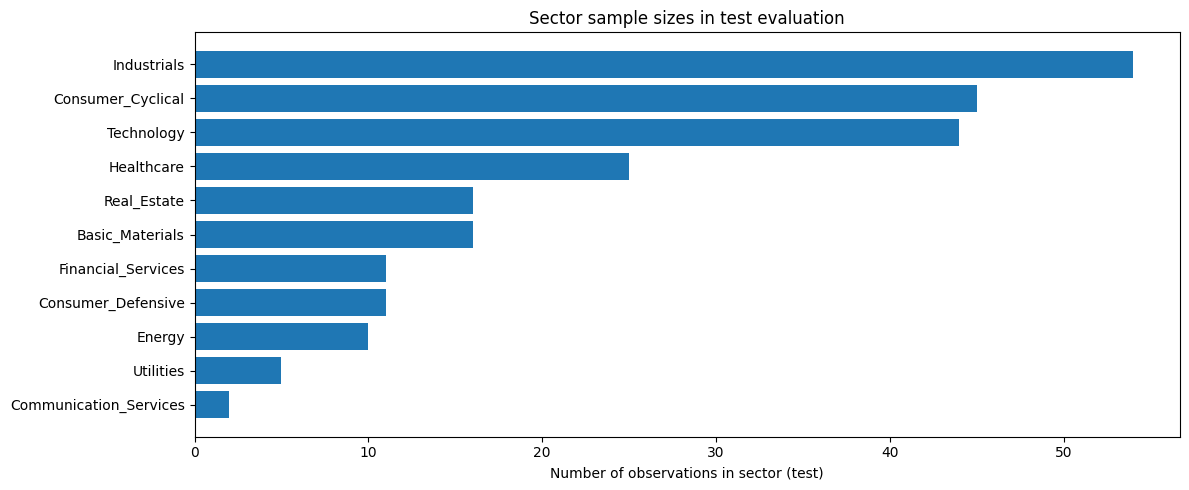

Prediction intervals for XGBoost (tuned): coverage=0.301, average width=3.831
       y_true  pred_mean   pred_p05   pred_p95  interval_width  covered
1126   6.3595   9.358189   7.994506  10.394864        2.400358    False
1064  13.7821   9.945780   8.810192  11.021271        2.211080    False
126    5.3407   9.103792   7.974607   9.910856        1.936249    False
1018   5.0441   7.934805   7.138886   9.057322        1.918437    False
922    6.6936   7.282908   5.868181   9.235177        3.366996     True
95     9.3147  12.360731  10.330952  14.889115        4.558162    False
413    5.0224   6.931128   5.913492   8.188266        2.274773    False
99     8.5153  10.915843   9.213197  12.143401        2.930204    False
425    9.1638  12.221840  10.397978  14.416897        4.018919    False
892    7.7737  11.596354   9.455776  13.284447        3.828671    False


In [73]:
random_state = int(globals().get('RANDOM_STATE', 42))
n_jobs = int(globals().get('N_JOBS', -1))

bootstrap_rng = np.random.default_rng(random_state)
bootstrap_iterations = 2000

bootstrap_reference_name = final_protocol_df.loc[0, 'Model']
bootstrap_reference_pred = np.asarray(r2_protocol_test_preds[bootstrap_reference_name])

bootstrap_rows = []
test_indices = np.arange(len(y_test))
y_test_array = y_test.to_numpy()

for model_name in final_protocol_df['Model'][1:]:
    candidate_pred = np.asarray(r2_protocol_test_preds[model_name])
    r2_diff_samples = []

    for _ in range(bootstrap_iterations):
        sample_idx = bootstrap_rng.choice(test_indices, size=len(test_indices), replace=True)
        r2_ref = r2_score(y_test_array[sample_idx], bootstrap_reference_pred[sample_idx])
        r2_cmp = r2_score(y_test_array[sample_idx], candidate_pred[sample_idx])
        r2_diff_samples.append(r2_ref - r2_cmp)

    r2_diff_samples = np.asarray(r2_diff_samples)
    bootstrap_rows.append({
        'Model_ref': bootstrap_reference_name,
        'Model_cmp': model_name,
        'R2_diff_mean': float(np.mean(r2_diff_samples)),
        'R2_diff_q025': float(np.quantile(r2_diff_samples, 0.025)),
        'R2_diff_q975': float(np.quantile(r2_diff_samples, 0.975)),
        'P_ref_better': float(np.mean(r2_diff_samples > 0)),
    })

bootstrap_diff_df = pd.DataFrame(bootstrap_rows).sort_values(by='R2_diff_mean', ascending=False).reset_index(drop=True)
print('Bootstrap R2 differences relative to the best model from CV ranking:')
print(bootstrap_diff_df)

sector_eval_df = pd.DataFrame({
    'Sector': sector_labels_test,
    'y_true': y_test,
    'y_pred': selected_r2_test_pred,
})

sector_stability_rows = []
for sector_name, sector_group in sector_eval_df.groupby('Sector'):
    y_true_sector = sector_group['y_true']
    y_pred_sector = sector_group['y_pred']
    sector_stability_rows.append({
        'Sector': sector_name,
        'Count': int(len(sector_group)),
        'R2': float(r2_score(y_true_sector, y_pred_sector)) if len(sector_group) >= 3 and y_true_sector.nunique() > 1 else np.nan,
        'MAE': float(mean_absolute_error(y_true_sector, y_pred_sector)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true_sector, y_pred_sector))),
        'MAPE (%)': float(mape(y_true_sector, y_pred_sector)),
    })

sector_stability_df = pd.DataFrame(sector_stability_rows).sort_values(by='Count', ascending=False).reset_index(drop=True)
print('Sector stability for the model selected by R2:')
print(sector_stability_df)

plt.figure(figsize=(12, 5))
sector_plot_df = sector_stability_df.sort_values(by='Count', ascending=True)
plt.barh(sector_plot_df['Sector'], sector_plot_df['Count'])
plt.xlabel('Number of observations in sector (test)')
plt.title('Sector sample sizes in test evaluation')
plt.tight_layout()
plt.show()

bootstrap_model_name = 'XGBoost (tuned)'
bootstrap_base_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=random_state,
    n_jobs=n_jobs,
    **best_xgb_params,
    )
bootstrap_model_count = 40
bootstrap_pred_matrix = np.zeros((bootstrap_model_count, X_test.shape[0]))
train_boot_idx = np.arange(X_train.shape[0])

for bootstrap_iter in range(bootstrap_model_count):
    sample_idx = bootstrap_rng.choice(train_boot_idx, size=len(train_boot_idx), replace=True)
    X_boot = X_train.iloc[sample_idx]
    y_boot = y_train.iloc[sample_idx]

    bootstrap_model = clone(bootstrap_base_model)
    bootstrap_model.fit(X_boot, y_boot)
    bootstrap_pred_matrix[bootstrap_iter] = bootstrap_model.predict(X_test)

prediction_interval_df = pd.DataFrame({
    'y_true': y_test.to_numpy(),
    'pred_mean': bootstrap_pred_matrix.mean(axis=0),
    'pred_p05': np.quantile(bootstrap_pred_matrix, 0.05, axis=0),
    'pred_p95': np.quantile(bootstrap_pred_matrix, 0.95, axis=0),
}, index=y_test.index)
prediction_interval_df['interval_width'] = prediction_interval_df['pred_p95'] - prediction_interval_df['pred_p05']
prediction_interval_df['covered'] = (prediction_interval_df['y_true'] >= prediction_interval_df['pred_p05']) & (prediction_interval_df['y_true'] <= prediction_interval_df['pred_p95'])

coverage = prediction_interval_df['covered'].mean()
avg_interval_width = prediction_interval_df['interval_width'].mean()
print(f'Prediction intervals for {bootstrap_model_name}: coverage={coverage:.3f}, average width={avg_interval_width:.3f}')
print(prediction_interval_df.head(10))

## Uncertainty and stability diagnostics: interpretation

Purpose: quantify whether the selected model advantage is statistically meaningful and assess prediction uncertainty.

Result: bootstrap comparison reports a positive mean $R^2$ gap versus WLS (about $0.084$), and the lower 95% quantile remains above zero, indicating a robust advantage for the selected model. Prediction-interval diagnostics for tuned XGBoost show coverage around $0.301$ with average width about $3.831$.

Meaning: ranking stability is supported, but interval coverage indicates that simple bootstrap bands are relatively narrow for observed variability; point forecasts are useful, while interval calibration may need refinement for risk-sensitive use cases.

In [64]:
if 'shap_global_df' in globals() and 'shap_values' in globals() and 'X_xai_sample' in globals():
    economic_xai_rows = []
    top_features_for_econ = shap_global_df['Feature'].head(10).tolist()

    for feature_name in top_features_for_econ:
        feature_pos = list(X_xai_sample.columns).index(feature_name)
        feature_values = X_xai_sample[feature_name].to_numpy()
        shap_feature_values = shap_values.values[:, feature_pos]
        feature_target_corr = np.corrcoef(X_train[feature_name], y_train)[0, 1] if X_train[feature_name].nunique() > 1 else np.nan
        feature_shap_corr = np.corrcoef(feature_values, shap_feature_values)[0, 1] if np.unique(feature_values).size > 1 else np.nan
        mean_shap = float(np.mean(shap_feature_values))

        economic_xai_rows.append({
            'Feature': feature_name,
            'MeanAbsSHAP': float(np.abs(shap_feature_values).mean()),
            'MeanSHAP': mean_shap,
            'Corr(feature, target_train)': feature_target_corr,
            'Corr(feature, SHAP)': feature_shap_corr,
            'Suggested direction': 'higher feature -> higher valuation' if np.nan_to_num(feature_shap_corr) > 0 else 'higher feature -> lower valuation',
        })

    economic_xai_df = pd.DataFrame(economic_xai_rows).sort_values(by='MeanAbsSHAP', ascending=False).reset_index(drop=True)
    print('Table for economic interpretation of top XGBoost features:')
    print(economic_xai_df)
else:
    print('Economic interpretation table skipped: first run the XAI section.')

Table for economic interpretation of top XGBoost features:
              Feature  MeanAbsSHAP  MeanSHAP  Corr(feature, target_train)  \
0   grossProfitMargin     0.705866  0.114488                     0.208034   
1  R_and_D_to_Revenue     0.637233  0.110670                     0.246196   
2      Dividend_Yield     0.626450 -0.078499                    -0.143660   
3      Revenue_Growth     0.578494  0.006415                     0.050890   
4       assetTurnover     0.570266  0.076333                    -0.221252   
5      returnOnEquity     0.519242  0.005233                    -0.164824   
6   Sector_Healthcare     0.517274  0.163182                     0.272265   
7       Profit_Margin     0.450895  0.018717                     0.001347   
8    Capex_to_Revenue     0.399954 -0.068514                    -0.030951   
9      Debt_to_Equity     0.319037 -0.005673                    -0.021817   

   Corr(feature, SHAP)                 Suggested direction  
0             0.743754  higher f

## Reading the economic XAI table: direct business interpretation

Purpose: translate the `economic_xai_df` output into valuation conclusions that can be used in reporting.

Interpretation rules for each row:
- `MeanAbsSHAP`: strength of valuation influence.
- `MeanSHAP`: average net push direction (upward vs downward pressure on EV/EBITDA).
- `Corr(feature, target_train)`: raw association with the observed target.
- `Corr(feature, SHAP)`: model-implied directional effect after conditioning on other variables.
- `Suggested direction`: quick directional summary for decision notes.

Practical use:
- Prioritize the top 5-10 variables by `MeanAbsSHAP` as the core valuation narrative.
- Use `Corr(feature, SHAP)` to state whether increasing a variable tends to raise or lower predicted EV/EBITDA in this sample.
- If `Corr(feature, target_train)` and `Corr(feature, SHAP)` disagree, treat this as evidence of interaction/non-linearity and discuss conditional effects rather than simple one-variable stories.
- For large prediction errors, use local waterfalls to identify whether misspecification is driven by sector effects, extreme ratio combinations, or low-support regions in feature space.

## Final conclusion

This notebook compares econometric and machine-learning alternatives on the same split, then validates the ranking with repeated-CV and bootstrap diagnostics.

Final model choice: **XGBoost (tuned)**.

Why this model is selected:
- It delivers the best top-line predictive performance in the core comparison (test $R^2 \approx 0.331$).
- It remains top-ranked in the R2-first protocol based on repeated cross-validation.
- Bootstrap gap analysis supports a stable advantage versus weaker benchmarks (for example WLS).
- XAI outputs provide interpretable variable-level and observation-level explanations, which improves usability for valuation analysis.

How to interpret the modeling result substantively:
- EV/EBITDA variation is explainable to a meaningful degree by financial-ratio structure and sector context, but not fully exhausted by the current feature space.
- Non-linear tree modeling captures this structure better than linear alternatives in this dataset.
- The final valuation narrative should rely on:
  (a) global driver ranking from SHAP/permutation importance,
  (b) directional SHAP effects for practical economic interpretation,
  (c) local waterfall diagnostics for case-level justification.

Practical recommendation: use tuned XGBoost as the primary valuation engine, and keep WLS/linear models as transparency baselines and robustness references rather than primary predictors.